### KALIBRASI


analisis data tunggal


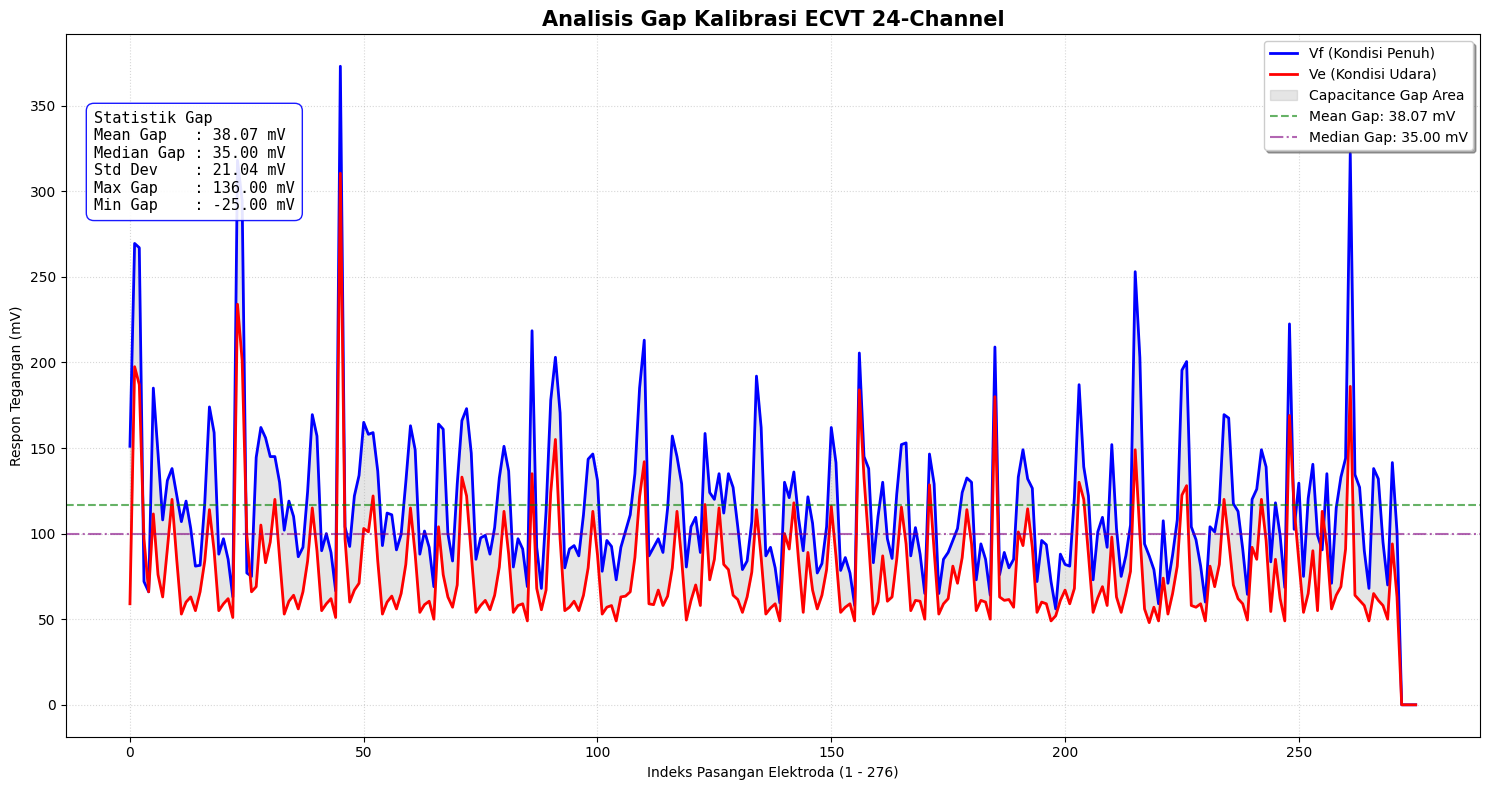

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_enhanced_gap_analysis_12ch(file_path):
    try:
        # 1. Loading Data
        mat_data = scipy.io.loadmat(file_path)
        
        # Mengekstrak dari struct 'bes' (Struktur khusus file 12ch Anda)
        bes = mat_data['bes'][0, 0]
        ve = bes['Ve'].flatten() # Data Udara
        vf = bes['Vf'].flatten() # Data Air
        
        # Penanganan Indeks (Sesuai jumlah data: 66)
        indices = np.arange(len(ve))
            
        # --- PERHITUNGAN STATISTIK GAP ---
        # Gap biasanya didefinisikan sebagai (Vf - Ve)
        gap = vf - ve
        mean_gap = np.mean(gap)
        median_gap = np.median(gap) 
        std_gap = np.std(gap)
        max_gap = np.max(gap)
        min_gap = np.min(gap)

        # 2. Plotting
        plt.figure(figsize=(15, 8))
        
        # Plot Garis Vf dan Ve
        plt.plot(indices, vf, label='Vf (Kondisi Penuh)', color='blue', linewidth=2)
        plt.plot(indices, ve, label='Ve (Kondisi Udara)', color='red', linewidth=2)
        
        # Arsir Gap area
        plt.fill_between(indices, ve, vf, color='gray', alpha=0.2, label='Capacitance Gap Area')

        # Garis Horizontal Statistik
        plt.axhline(y=np.mean(ve) + mean_gap, color='green', linestyle='--', alpha=0.6, 
                    label=f'Mean Gap: {mean_gap:.2f} mV')
        plt.axhline(y=np.median(ve) + median_gap, color='purple', linestyle='-.', alpha=0.6, 
                    label=f'Median Gap: {median_gap:.2f} mV')

        # 3. Styling & Annotations
        plt.title(f'Analisis Gap Kalibrasi ECVT 24-Channel', fontweight='bold', fontsize=15)
        plt.xlabel('Indeks Pasangan Elektroda (1 - 276)')
        plt.ylabel('Respon Tegangan (mV)')
        
        # Box Statistik
        stats_box = (
            f"Statistik Gap\n"
            f"Mean Gap   : {mean_gap:.2f} mV\n"
            f"Median Gap : {median_gap:.2f} mV\n"
            f"Std Dev    : {std_gap:.2f} mV\n"
            f"Max Gap    : {max_gap:.2f} mV\n"
            f"Min Gap    : {min_gap:.2f} mV"
        )
        
        plt.annotate(stats_box, xy=(0.02, 0.75), xycoords='axes fraction', 
                     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="blue", alpha=0.9),
                     fontsize=11, family='monospace')

        plt.legend(loc='upper right', frameon=True, shadow=True)
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan fungsi dengan path file Anda
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat'
plot_enhanced_gap_analysis_12ch(file_path)

analisis data tunggal persebaran fluktuasi dan gap


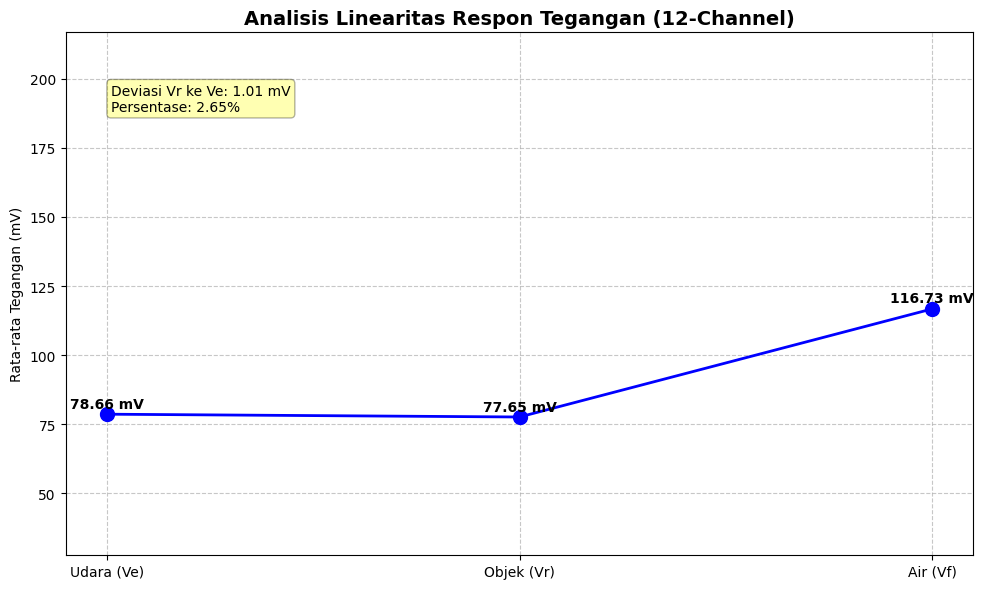

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_linearity_12ch(file_path):
    try:
        # 1. Loading Data
        data = scipy.io.loadmat(file_path)
        
        # Masuk ke struct 'bes' 
        bes = data['bes'][0, 0]
        
        # Ekstrak data (Pastikan nama key sesuai output: Ve, Vf, Vrt) 
        ve = bes['Ve'].flatten()      # Udara
        vf = bes['Vf'].flatten()      # Air (Penuh)
        vrt = bes['Vrt']             # Objek (Matriks 25 frame)
        
        # 2. Hitung Rata-rata Tegangan Global
        # Untuk Vrt, kita ambil rata-rata dari seluruh frame dan seluruh elektroda
        ve_avg = np.mean(ve)
        vf_avg = np.mean(vf)
        vr_avg = np.mean(vrt)
        deviasi = abs(vr_avg - ve_avg)
        deviasi_persen = (deviasi / (vf_avg - ve_avg)) * 100
        
        # 3. Plotting
        plt.figure(figsize=(10, 6))
        
        labels = ['Udara (Ve)', 'Objek (Vr)', 'Air (Vf)']
        values = [ve_avg, vr_avg, vf_avg]
        stats_text = f"Deviasi Vr ke Ve: {deviasi:.2f} mV\nPersentase: {deviasi_persen:.2f}%"
        plt.annotate(stats_text, xy=(0.05, 0.85), xycoords='axes fraction', 
             bbox=dict(boxstyle="round", fc="yellow", alpha=0.3))
        
        # Membuat grafik garis linearitas
        plt.plot(labels, values, marker='o', markersize=10, linewidth=2, color='blue', label='Respon Sensor')
        
        # Tambahkan Label Nilai di Setiap Titik
        for i, v in enumerate(values):
            plt.text(i, v + (max(values)*0.02), f'{v:.2f} mV', ha='center', fontweight='bold')

        plt.title('Analisis Linearitas Respon Tegangan (12-Channel)', fontsize=14, fontweight='bold')
        plt.ylabel('Rata-rata Tegangan (mV)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(min(values) - 50, max(values) + 100)
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error Terdeteksi: {e}")

# Masukkan path file Anda di sini
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat'
plot_linearity_12ch(file_path)

### ANALISIS STABILITAS (TEMPLATE)


analisis data mentah dan SNR


File 1 diproses: 276 elektroda, 25 frames.
File 2 diproses: 276 elektroda, 25 frames.
File 3 diproses: 276 elektroda, 25 frames.


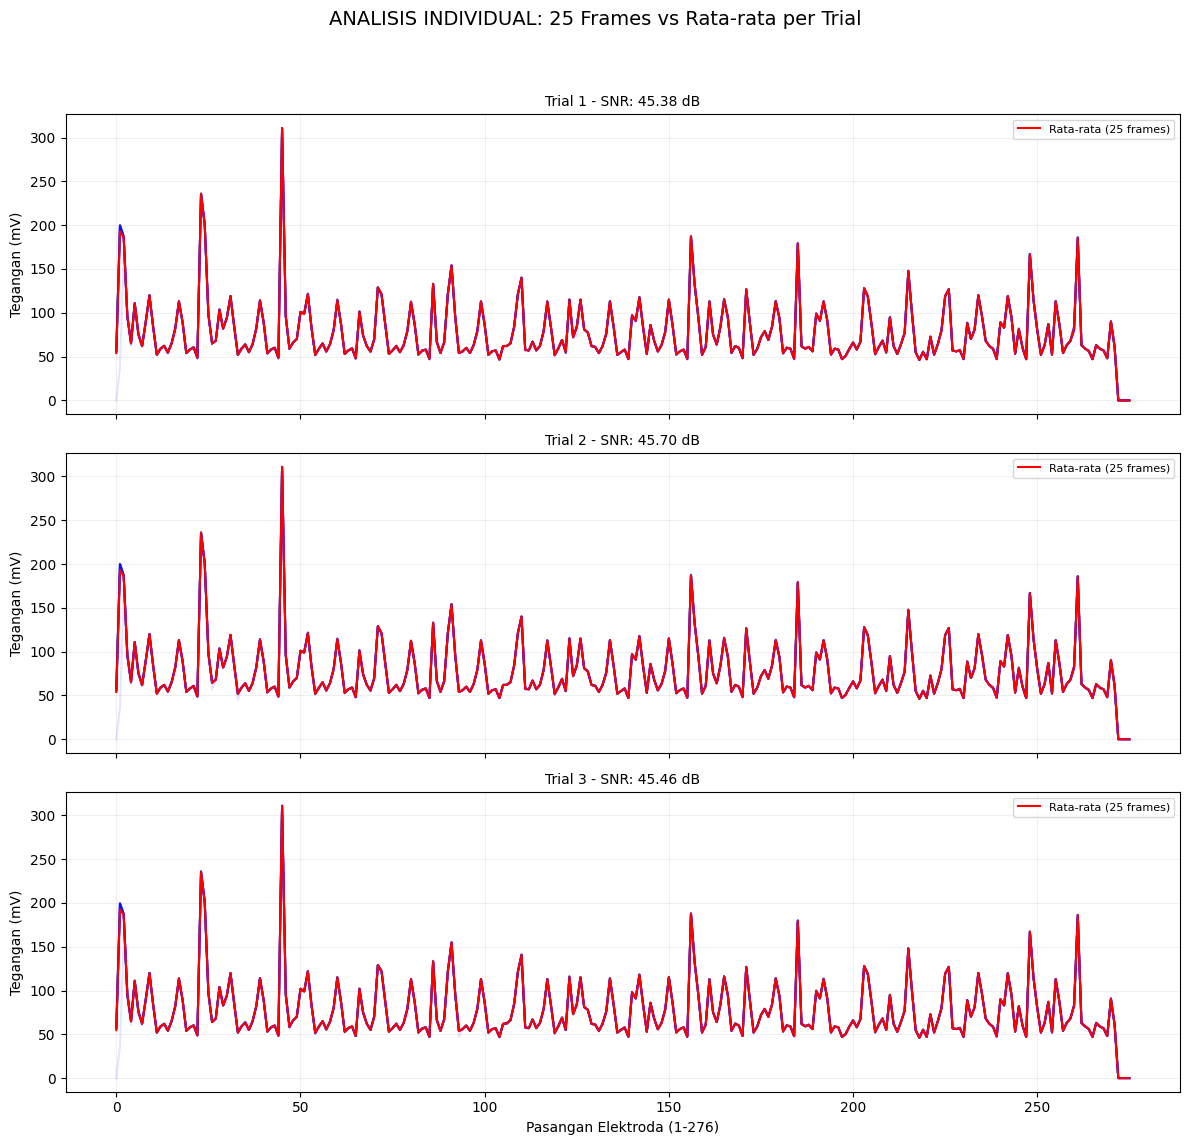

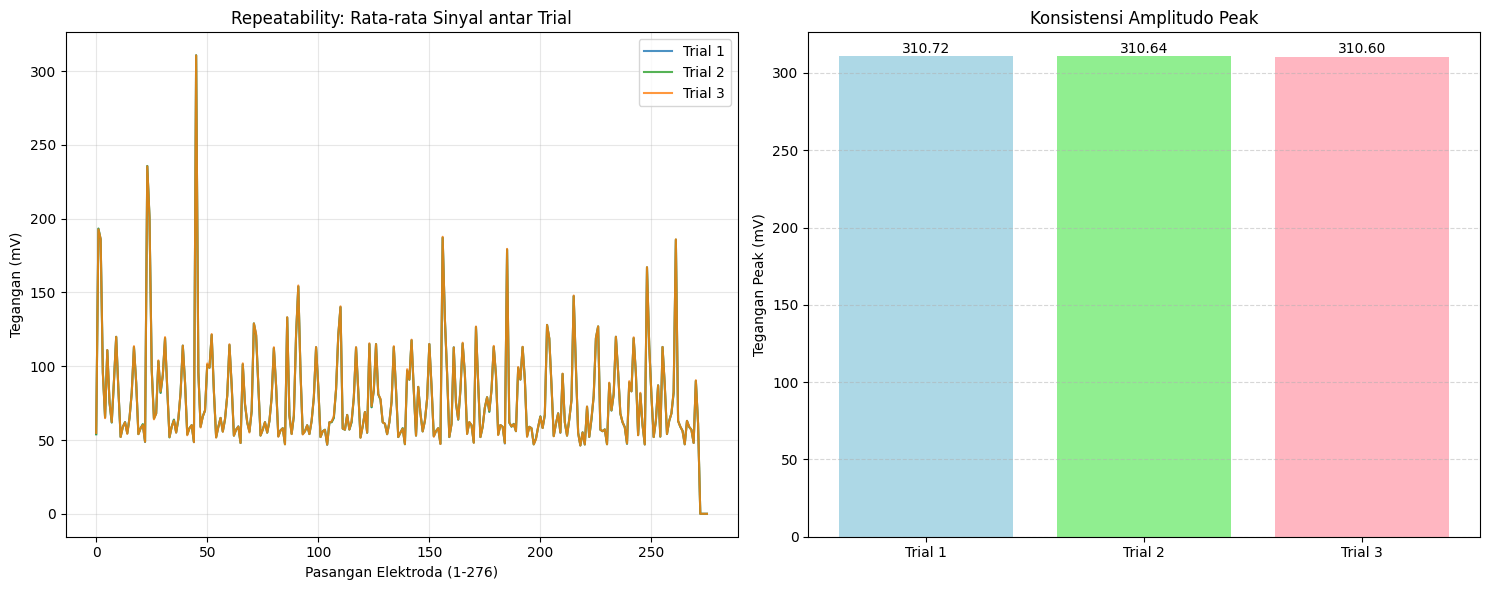


TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-----------------------------------------------------------------
Trial 1    | 45.38      | 310.72     | 0.4181
Trial 2    | 45.70      | 310.64     | 0.4027
Trial 3    | 45.46      | 310.60     | 0.4147
-----------------------------------------------------------------
Stabilitas Sinyal (RSD) : 0.02 %


In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Daftar file yang akan diolah
file_paths = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_komprehensif_ecvt_v2(paths):
    all_results = []
    
    # --- 1. PROSES DATA PER FILE ---
    for i, path in enumerate(paths):
        try:
            mat = scipy.io.loadmat(path)
            # Mengakses struct 'bes' dan field 'Vrt'
            # Format (25, 276) -> Dimensi 0: Frames, Dimensi 1: Pasangan Elektroda
            raw_data = mat['bes'][0, 0]['Vrt']
            
            # Jika data 3D (misal ada dimensi frekuensi), ambil indeks frekuensi ke-3
            if raw_data.ndim == 3:
                vr_frames = raw_data[:, :, 3].T # Transpose agar menjadi (276, 25)
            else:
                vr_frames = raw_data.T # Transpose (25, 276) -> (276, 25)
            
            # Sekarang: Baris = 276 (Pasangan), Kolom = 25 (Frames)
            mean_ch = np.mean(vr_frames, axis=1)
            std_ch = np.std(vr_frames, axis=1)
            
            # Hitung SNR
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            
            all_results.append({
                'name': f'Trial {i+1}',
                'mean': mean_ch,
                'std': std_ch,
                'snr': snr,
                'raw': vr_frames, # 25 garis
                'peak': np.max(mean_ch)
            })
            print(f"File {i+1} diproses: {vr_frames.shape[0]} elektroda, {vr_frames.shape[1]} frames.")

        except Exception as e:
            print(f"Error pada file {path}: {e}")

    if not all_results:
        return

    # --- 2. VISUALISASI INDIVIDUAL (Stabilitas Temporal) ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    fig.suptitle('ANALISIS INDIVIDUAL: 25 Frames vs Rata-rata per Trial', fontsize=14)
    
    for i, res in enumerate(all_results):
        # Plot 25 frame (Garis tipis biru)
        axes[i].plot(res['raw'], color='blue', alpha=0.1) 
        # Plot rata-rata (Garis tebal merah)
        axes[i].plot(res['mean'], color='red', linewidth=1.5, label=f"Rata-rata (25 frames)")
        
        axes[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
        axes[i].set_ylabel('Tegangan (mV)')
        axes[i].legend(loc='upper right', fontsize=8)
        axes[i].grid(True, alpha=0.2)
    
    plt.xlabel('Pasangan Elektroda (1-276)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 3. VISUALISASI GABUNGAN (Repeatability antar Trial) ---
    plt.figure(figsize=(15, 6))
    
    # Subplot A: Perbandingan Rata-rata 3 Trial
    plt.subplot(1, 2, 1)
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    for i, res in enumerate(all_results):
        plt.plot(res['mean'], label=f"{res['name']}", color=colors[i], alpha=0.8)
    
    plt.title('Repeatability: Rata-rata Sinyal antar Trial')
    plt.xlabel('Pasangan Elektroda (1-276)')
    plt.ylabel('Tegangan (mV)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot B: Perbandingan Nilai Peak
    plt.subplot(1, 2, 2)
    trial_names = [r['name'] for r in all_results]
    peaks = [r['peak'] for r in all_results]
    bars = plt.bar(trial_names, peaks, color=['#add8e6', '#90ee90', '#ffb6c1'])
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom')

    plt.title('Konsistensi Amplitudo Peak')
    plt.ylabel('Tegangan Peak (mV)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # --- 4. OUTPUT STATISTIK ---
    peak_list = [r['peak'] for r in all_results]
    noise_list = [np.mean(r['std']) for r in all_results]
    rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

    print("\n" + "="*65)
    print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
    print("-" * 65)
    for i, res in enumerate(all_results):
        print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {noise_list[i]:.4f}")
    print("-" * 65)
    print(f"Stabilitas Sinyal (RSD) : {rsd_sinyal:.2f} %")
    print("="*65)

# Jalankan alur
analisis_komprehensif_ecvt_v2(file_paths)

standar deviasi gabungan


File 1 diproses: 276 channel terdeteksi.
File 2 diproses: 276 channel terdeteksi.
File 3 diproses: 276 channel terdeteksi.


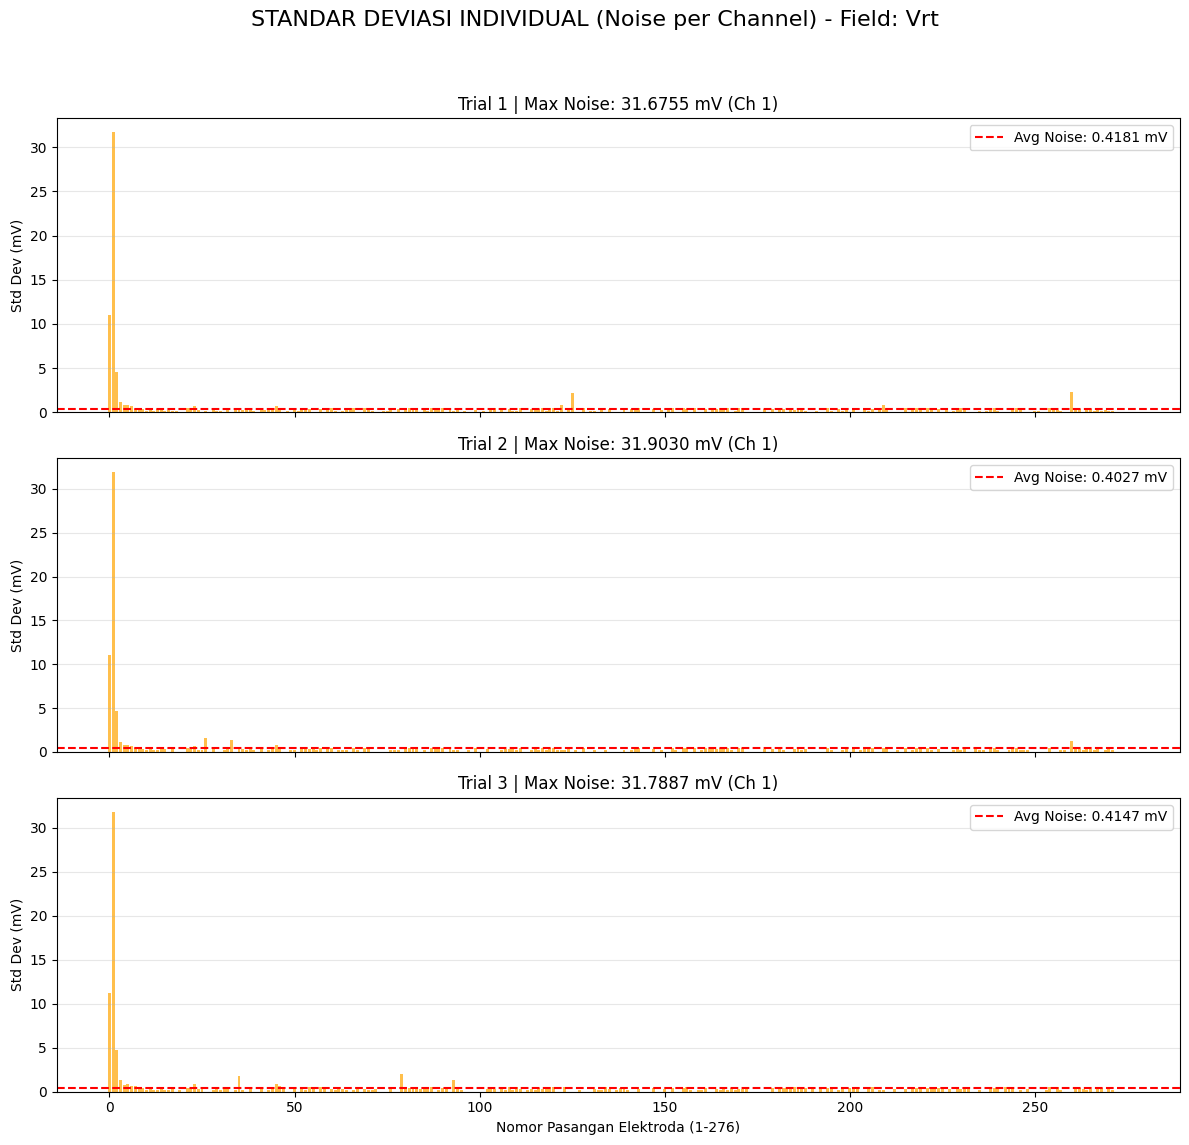

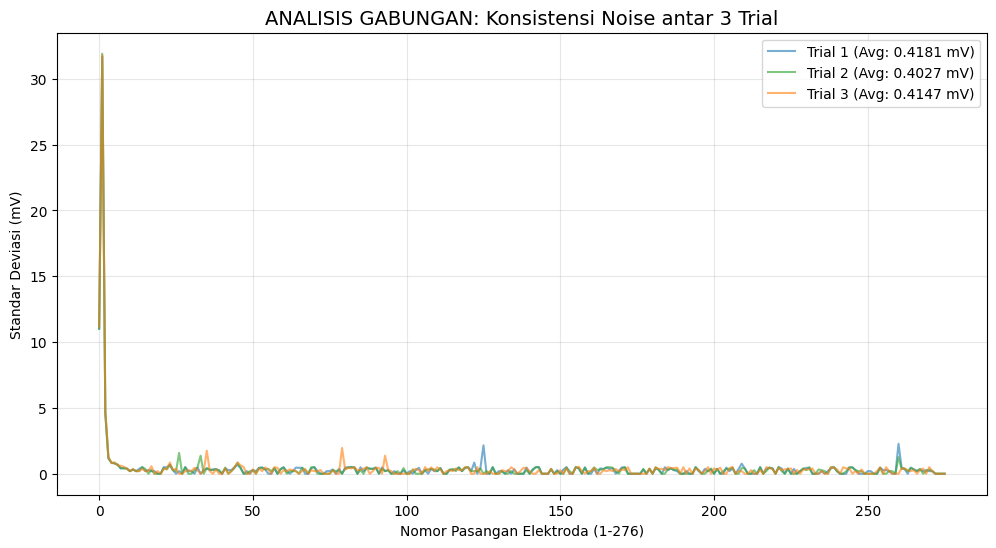


TRIAL      | AVG NOISE (mV)  | MAX NOISE (mV) 
-----------------------------------------------------------------
Trial 1    | 0.4181          | 31.6755        
Trial 2    | 0.4027          | 31.9030        
Trial 3    | 0.4147          | 31.7887        
-----------------------------------------------------------------
Variasi Noise antar Trial (RSD): 1.60 %


In [32]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Daftar file terbaru
file_paths = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_noise_bes_vrt(paths):
    all_std = []
    
    # --- 1. PROSES DATA PER FILE ---
    for i, path in enumerate(paths):
        try:
            mat = scipy.io.loadmat(path)
            # Mengakses struct 'bes' dan field 'Vrt'
            raw_data = mat['bes'][0, 0]['Vrt']
            
            # Penanganan Dimensi: (25, 276) -> Transpose menjadi (276, 25)
            # Baris: Pasangan Elektroda, Kolom: Frame (Waktu)
            if raw_data.ndim == 3:
                vr_frames = raw_data[:, :, 3].T 
            else:
                vr_frames = raw_data.T 
            
            # Hitung Standar Deviasi per channel (Noise Temporal)
            std_per_ch = np.std(vr_frames, axis=1)
            avg_noise = np.mean(std_per_ch)
            
            all_std.append({
                'name': f'Trial {i+1}',
                'std_data': std_per_ch,
                'avg_noise': avg_noise,
                'max_noise': np.max(std_per_ch),
                'max_ch': np.argmax(std_per_ch),
                'n_pairs': vr_frames.shape[0]
            })
            print(f"File {i+1} diproses: {vr_frames.shape[0]} channel terdeteksi.")

        except Exception as e:
            print(f"Error pada file {path}: {e}")

    if not all_std:
        return

    # --- 2. VISUALISASI INDIVIDUAL (GRAFIK BAR PER FILE) ---
    num_ch = all_std[0]['n_pairs']
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    fig.suptitle('STANDAR DEVIASI INDIVIDUAL (Noise per Channel) - Field: Vrt', fontsize=16)

    for i, res in enumerate(all_std):
        axes[i].bar(range(len(res['std_data'])), res['std_data'], color='orange', alpha=0.7)
        axes[i].axhline(y=res['avg_noise'], color='red', linestyle='--', 
                        label=f"Avg Noise: {res['avg_noise']:.4f} mV")
        
        axes[i].set_title(f"{res['name']} | Max Noise: {res['max_noise']:.4f} mV (Ch {res['max_ch']})")
        axes[i].set_ylabel('Std Dev (mV)')
        axes[i].legend(loc='upper right')
        axes[i].grid(axis='y', alpha=0.3)

    plt.xlabel(f'Nomor Pasangan Elektroda (1-{num_ch})')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 3. VISUALISASI GABUNGAN (PERBANDINGAN NOISE ANTAR TRIAL) ---
    plt.figure(figsize=(12, 6))
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    for i, res in enumerate(all_std):
        plt.plot(res['std_data'], label=f"{res['name']} (Avg: {res['avg_noise']:.4f} mV)", 
                 color=colors[i], alpha=0.6)

    plt.title('ANALISIS GABUNGAN: Konsistensi Noise antar 3 Trial', fontsize=14)
    plt.xlabel(f'Nomor Pasangan Elektroda (1-{num_ch})')
    plt.ylabel('Standar Deviasi (mV)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 4. RINGKASAN DATA & RSD ---
    print("\n" + "="*65)
    print(f"{'TRIAL':<10} | {'AVG NOISE (mV)':<15} | {'MAX NOISE (mV)':<15}")
    print("-" * 65)
    for res in all_std:
        print(f"{res['name']:<10} | {res['avg_noise']:<15.4f} | {res['max_noise']:<15.4f}")
    
    noise_vals = [r['avg_noise'] for r in all_std]
    rsd_noise = (np.std(noise_vals) / np.mean(noise_vals)) * 100
    print("-" * 65)
    print(f"Variasi Noise antar Trial (RSD): {rsd_noise:.2f} %")
    print("="*65)

# Jalankan fungsi
analisis_noise_bes_vrt(file_paths)

distribusi normalisasi gabungan



----- PASANGAN TERTINGGI (Trial 1) -----
Ranking    | Nomor Channel   | Nilai C-Norm
1          | 161             | 0.6009      
2          | 162             | 0.3973      
3          | 175             | 0.3704      
4          | 231             | 0.3148      
5          | 156             | 0.1433      

----- PASANGAN TERTINGGI (Trial 2) -----
Ranking    | Nomor Channel   | Nilai C-Norm
1          | 161             | 0.5963      
2          | 162             | 0.3973      
3          | 175             | 0.3704      
4          | 231             | 0.3270      
5          | 156             | 0.1451      

----- PASANGAN TERTINGGI (Trial 3) -----
Ranking    | Nomor Channel   | Nilai C-Norm
1          | 161             | 0.5981      
2          | 162             | 0.3973      
3          | 175             | 0.3704      
4          | 231             | 0.3426      
5          | 156             | 0.1730      


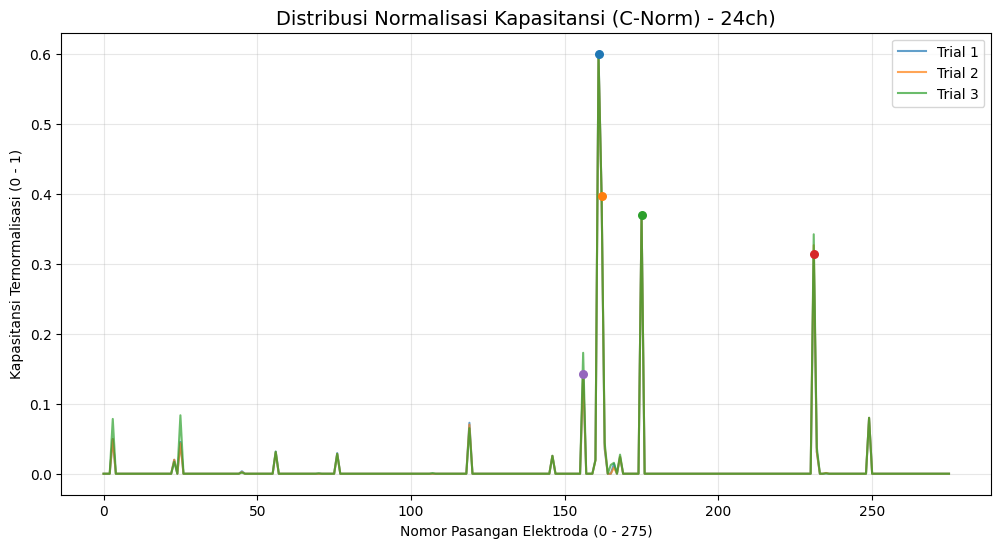

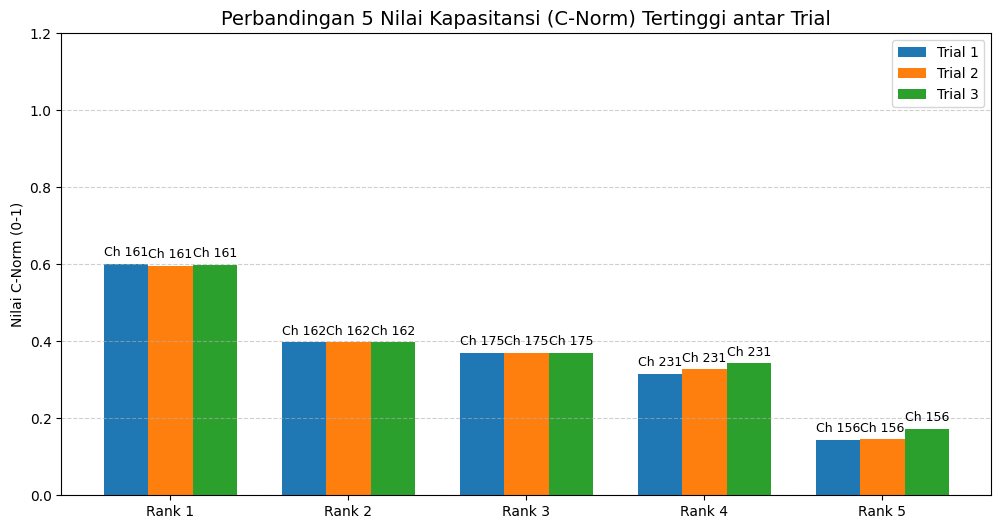

In [33]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Daftar file yang akan diolah
file_paths = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_normalisasi_detail(paths):
    try:
        # 1. Load referensi kalibrasi dari file pertama
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        
        # Ambil Ve dan Vf, lalu Transpose (25, 276) -> (276, 25) dan hitung rata-rata
        ve = np.mean(bes_ref['Ve'].T, axis=1) 
        vf = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf - ve
        gap[gap == 0] = 1e-10 # Safety division
        
        plt.figure(figsize=(12, 6))
        
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            
            # Ambil Vrt (Objek), Transpose dan rata-rata
            vr = np.mean(bes['Vrt'].T, axis=1) 
            
            # Perhitungan C-Norm
            cnorm = (vr - ve) / gap
            cnorm = np.clip(cnorm, 0, 1)
            
            # --- MENCARI TOP 5 TERTINGGI ---
            idx_sorted = np.argsort(cnorm)[::-1]
            top_5_idx = idx_sorted[:5]
            top_5_val = cnorm[top_5_idx]
            
            # Plot grafik utama
            plt.plot(cnorm, label=f'Trial {i+1}', alpha=0.7)
            
            # Tampilkan di Terminal
            print(f"\n----- PASANGAN TERTINGGI (Trial {i+1}) -----")
            print(f"{'Ranking':<10} | {'Nomor Channel':<15} | {'Nilai C-Norm':<12}")
            for rank, (idx, val) in enumerate(zip(top_5_idx, top_5_val)):
                print(f"{rank+1:<10} | {idx:<15} | {val:<12.4f}")
                if i == 0: # Tandai di grafik untuk Trial 1
                    plt.scatter(idx, val, s=30, zorder=5)

        plt.title('Distribusi Normalisasi Kapasitansi (C-Norm) - 24ch)', fontsize=14)
        plt.xlabel('Nomor Pasangan Elektroda (0 - 275)')
        plt.ylabel('Kapasitansi Ternormalisasi (0 - 1)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"Kesalahan pada detail: {e}")

def analisis_top5_cnorm(paths):
    try:
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        ve = np.mean(bes_ref['Ve'].T, axis=1) 
        vf = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf - ve
        gap[gap == 0] = 1e-10

        all_top5_indices = []
        all_top5_values = []

        for path in paths:
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            vr = np.mean(bes['Vrt'].T, axis=1) 
            cnorm = np.clip((vr - ve) / gap, 0, 1)
            
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            all_top5_indices.append(idx_sorted)
            all_top5_values.append(cnorm[idx_sorted])

        # --- VISUALISASI BAR CHART ---
        plt.figure(figsize=(12, 6))
        x = np.arange(5)
        width = 0.25

        for i in range(len(paths)):
            plt.bar(x + (i * width), all_top5_values[i], width, label=f'Trial {i+1}')
            for j, idx in enumerate(all_top5_indices[i]):
                plt.text(j + (i * width), all_top5_values[i][j] + 0.02, f"Ch {idx}", 
                         ha='center', fontsize=9)

        plt.title('Perbandingan 5 Nilai Kapasitansi (C-Norm) Tertinggi antar Trial', fontsize=14)
        plt.xticks(x + width, ['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        plt.ylabel('Nilai C-Norm (0-1)')
        plt.ylim(0, 1.2)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()

    except Exception as e:
        print(f"Kesalahan pada Top 5: {e}")

# Jalankan analisis
analisis_normalisasi_detail(file_paths)
analisis_top5_cnorm(file_paths)

### CENTER MENEMPEL


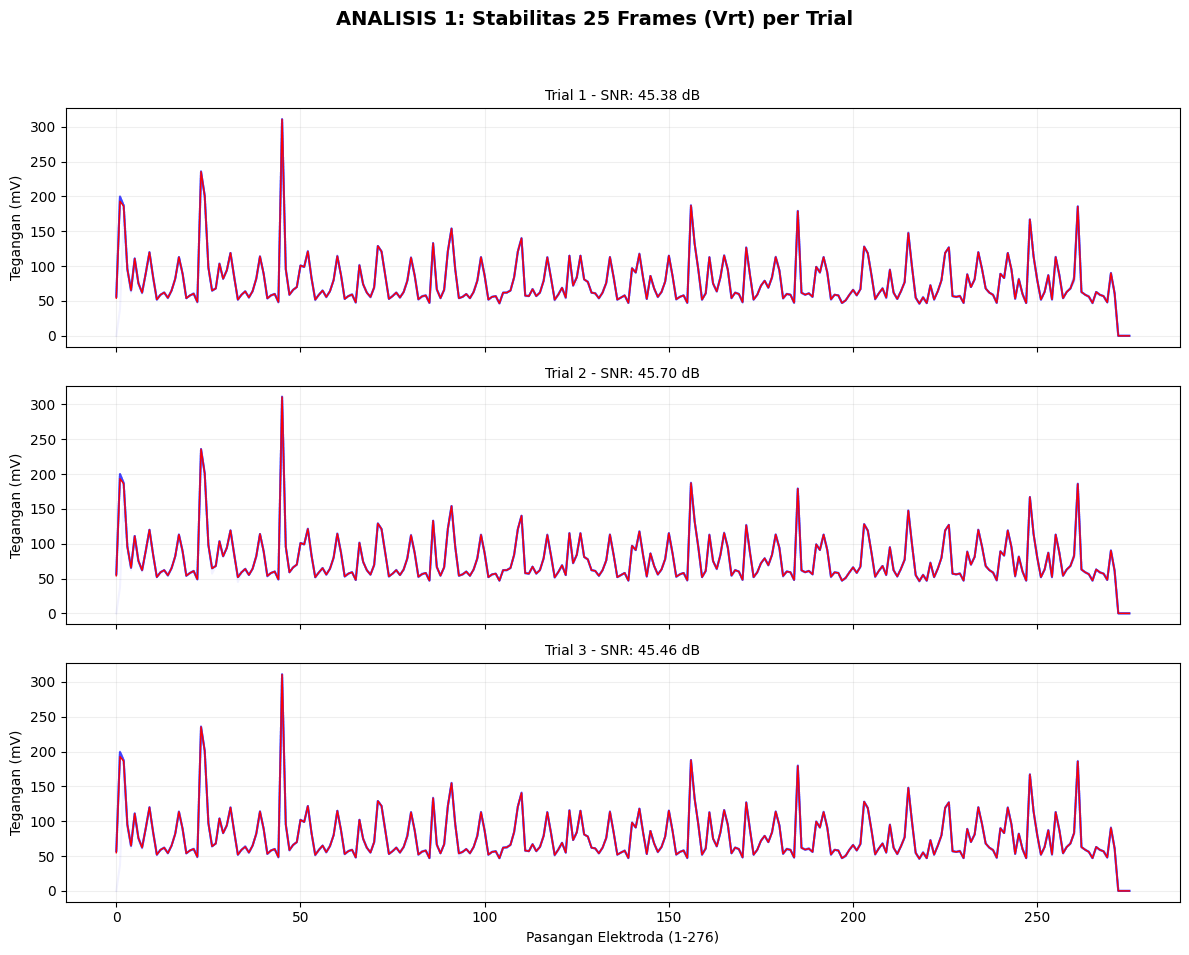

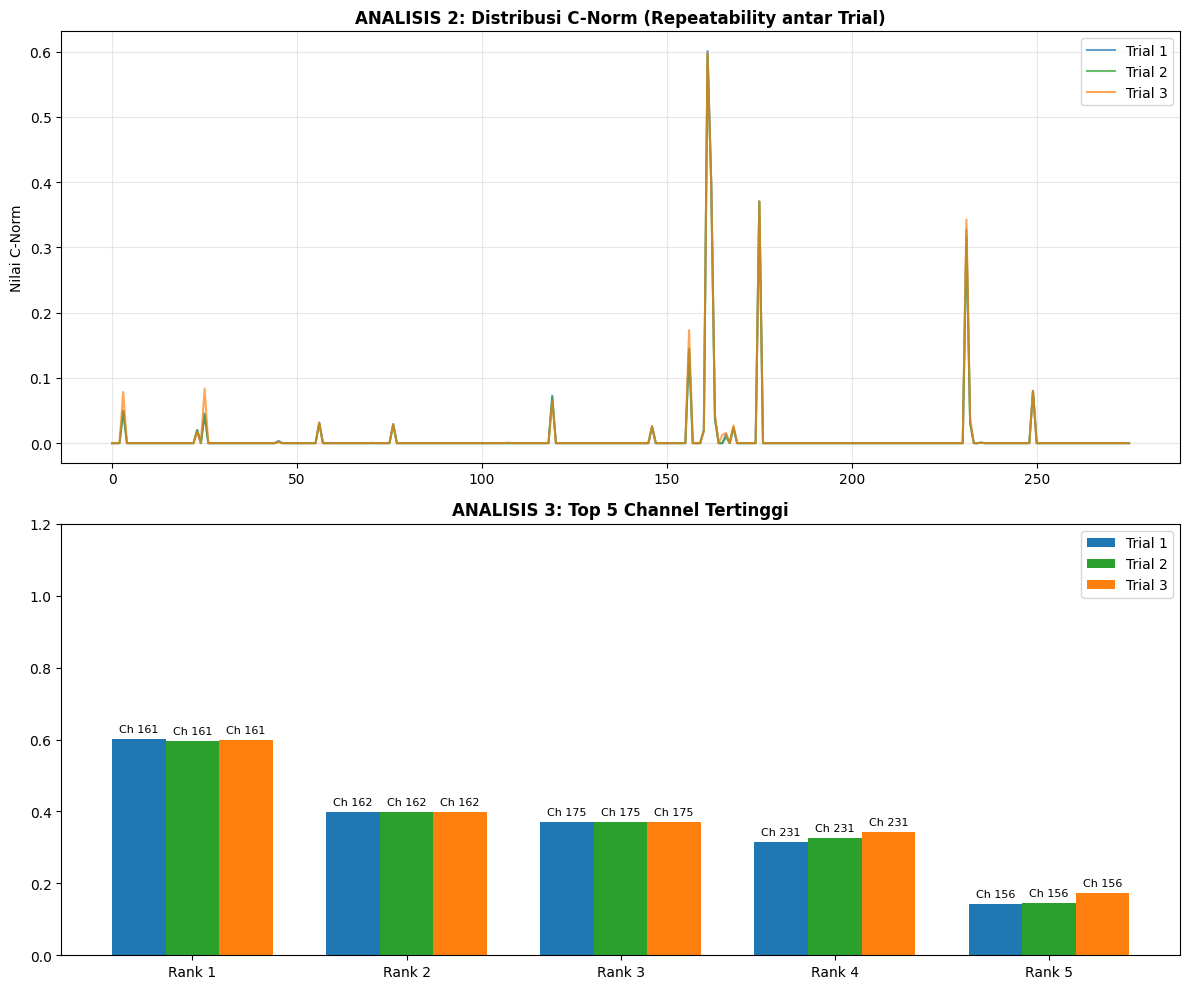


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 45.38      | 310.72     | 0.4181
Trial 2    | 45.70      | 310.64     | 0.4027
Trial 3    | 45.46      | 310.60     | 0.4147
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.02 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 161 | 0.6009        | 161 | 0.5963        | 161 | 0.5981        | 
 #2    | 162 |

In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### CENTER MENGAMBANG


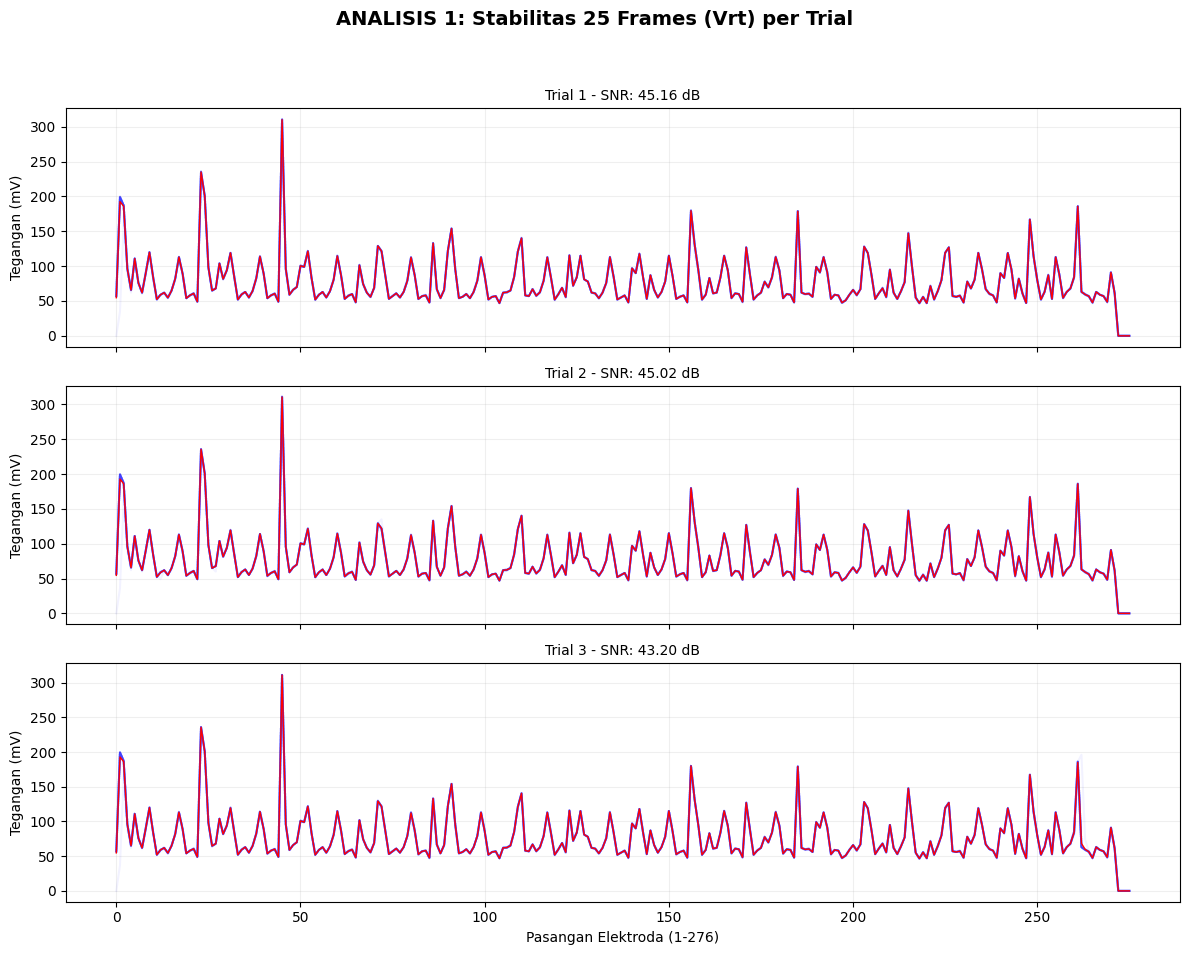

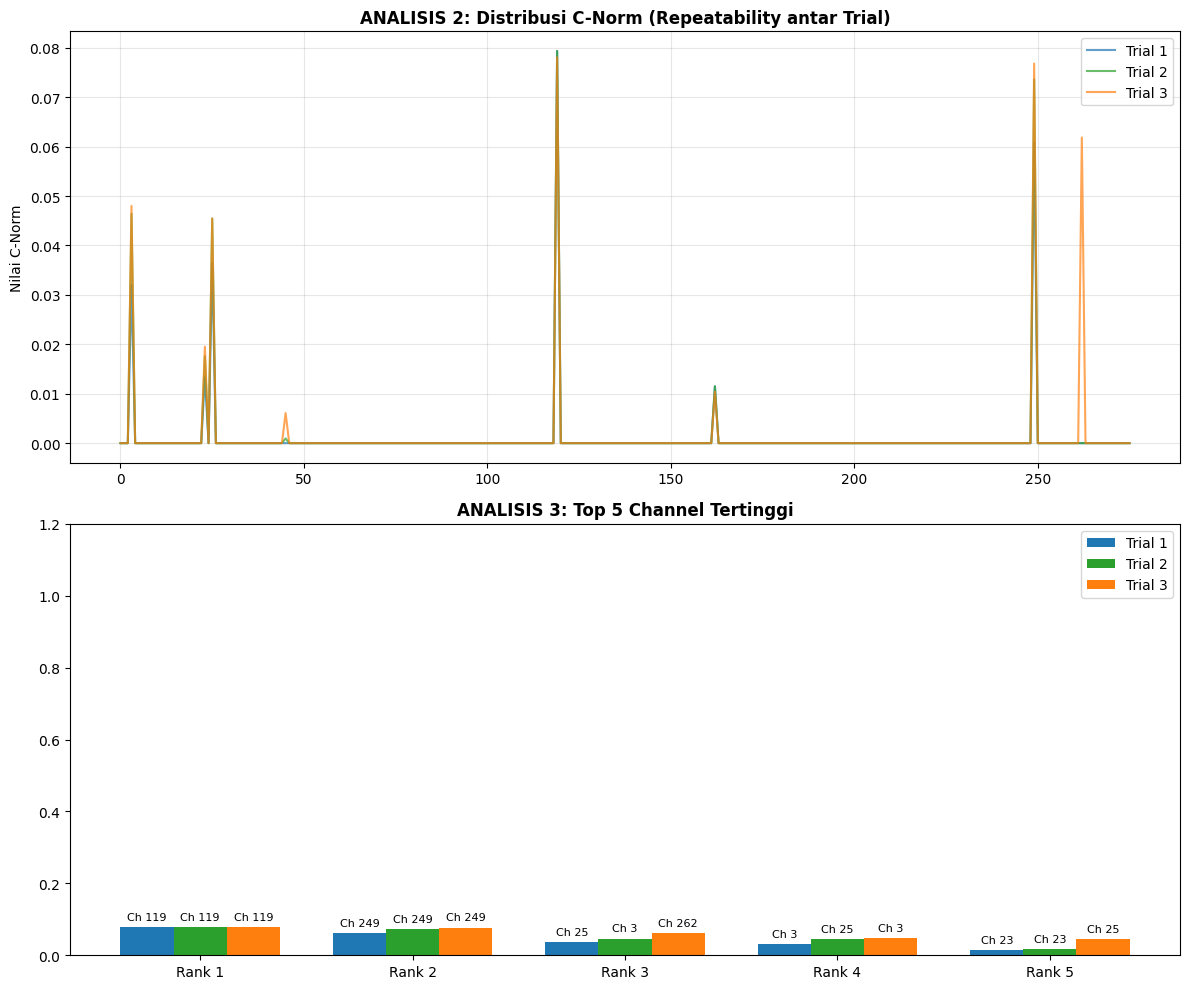


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 45.16      | 310.24     | 0.4276
Trial 2    | 45.02      | 310.56     | 0.4341
Trial 3    | 43.20      | 310.88     | 0.5360
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.08 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 119 | 0.0794        | 119 | 0.0794        | 119 | 0.0781        | 
 #2    | 249 |

In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_mengambang_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_mengambang_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_center_mengambang_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### KANAN DALAM


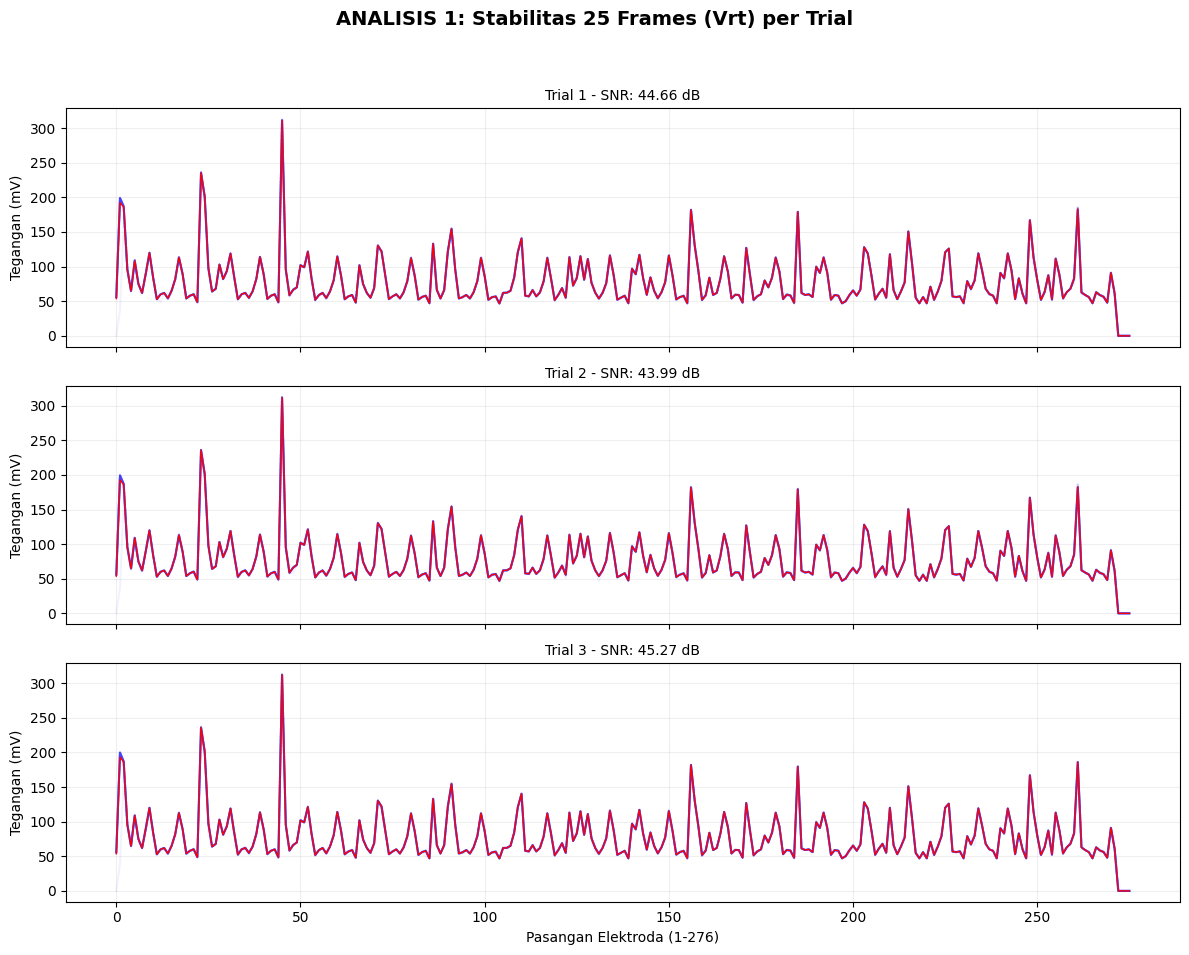

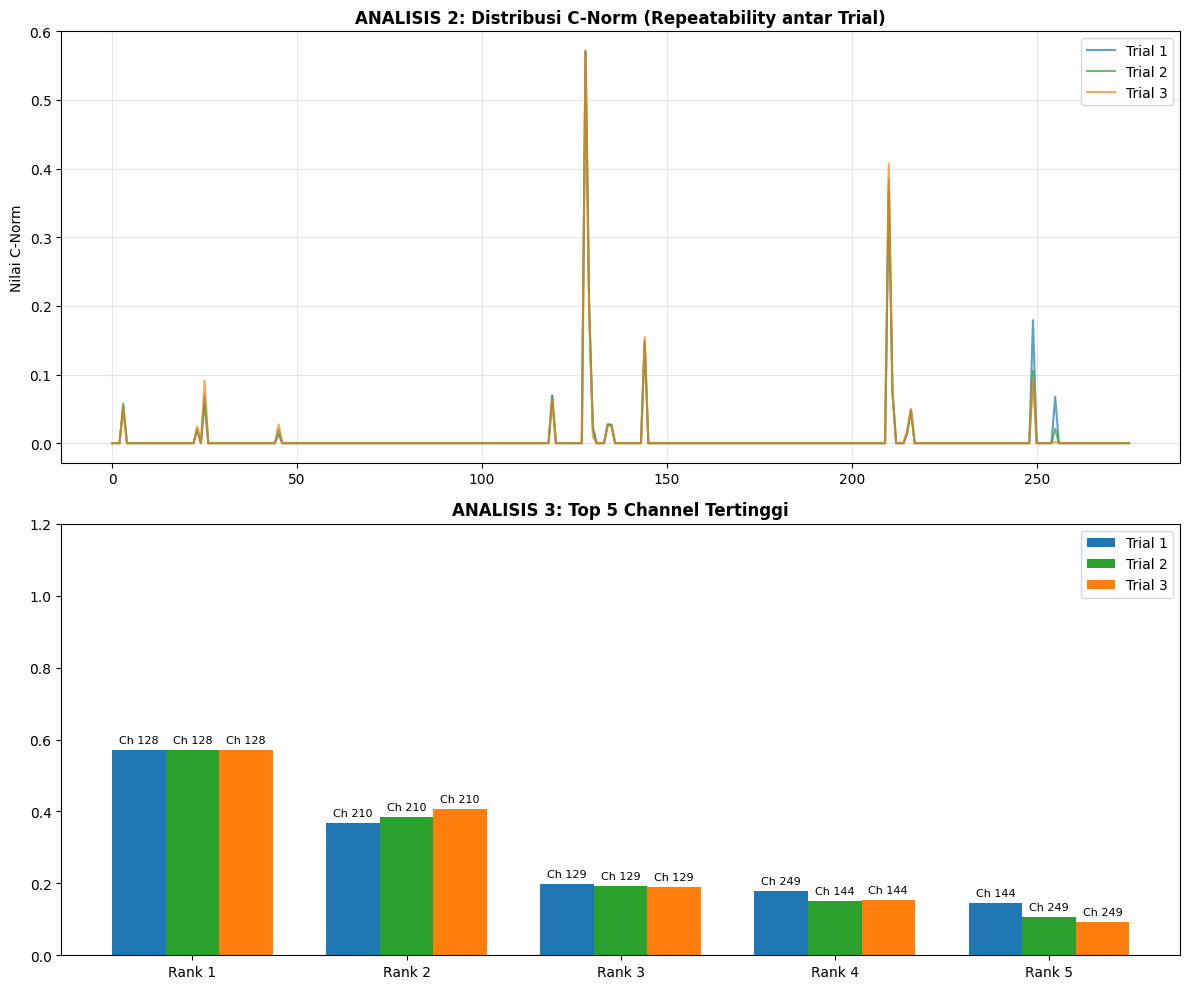


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 44.66      | 311.32     | 0.4538
Trial 2    | 43.99      | 311.72     | 0.4898
Trial 3    | 45.27      | 312.20     | 0.4227
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.12 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 128 | 0.5714        | 128 | 0.5714        | 128 | 0.5714        | 
 #2    | 210 |

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### KANAN LUAR


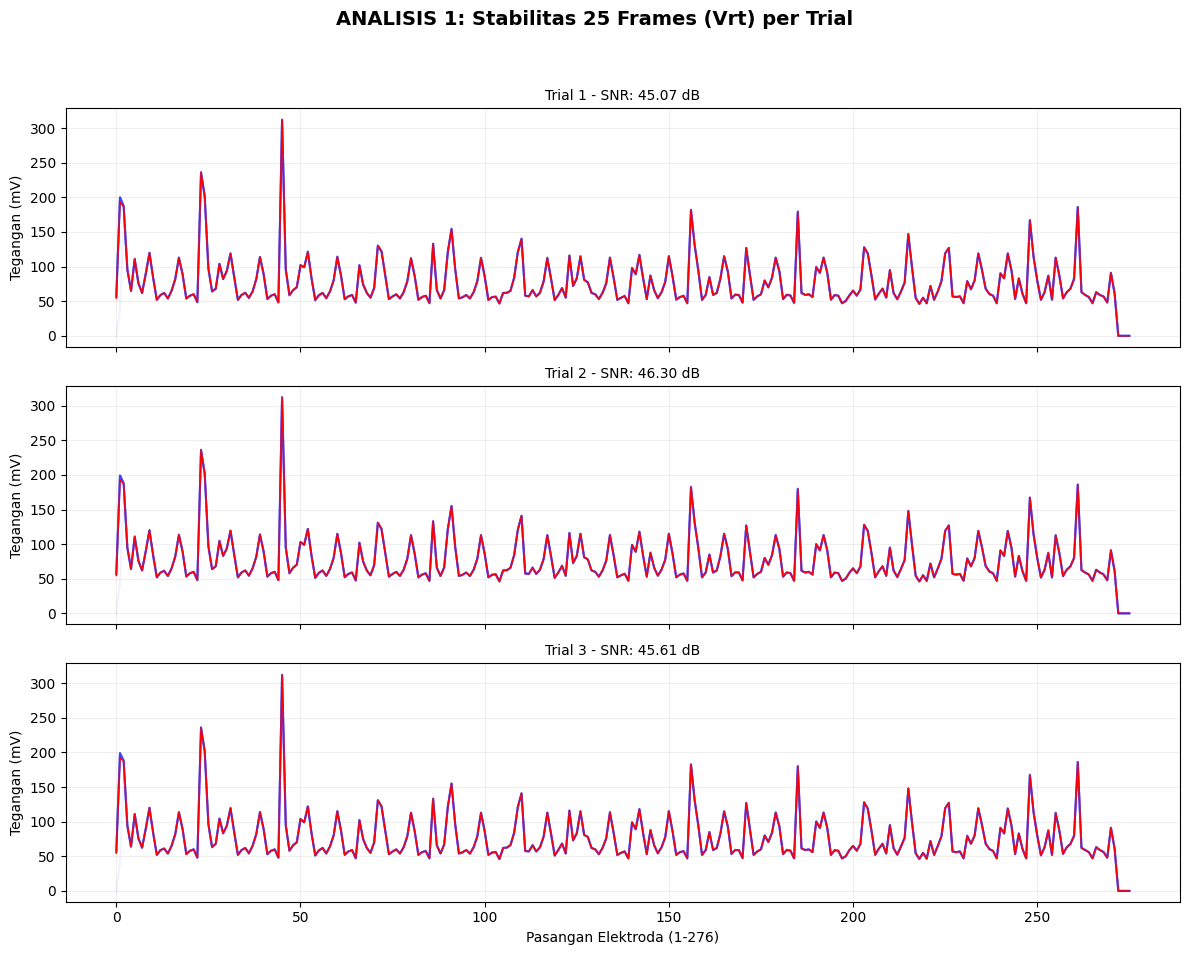

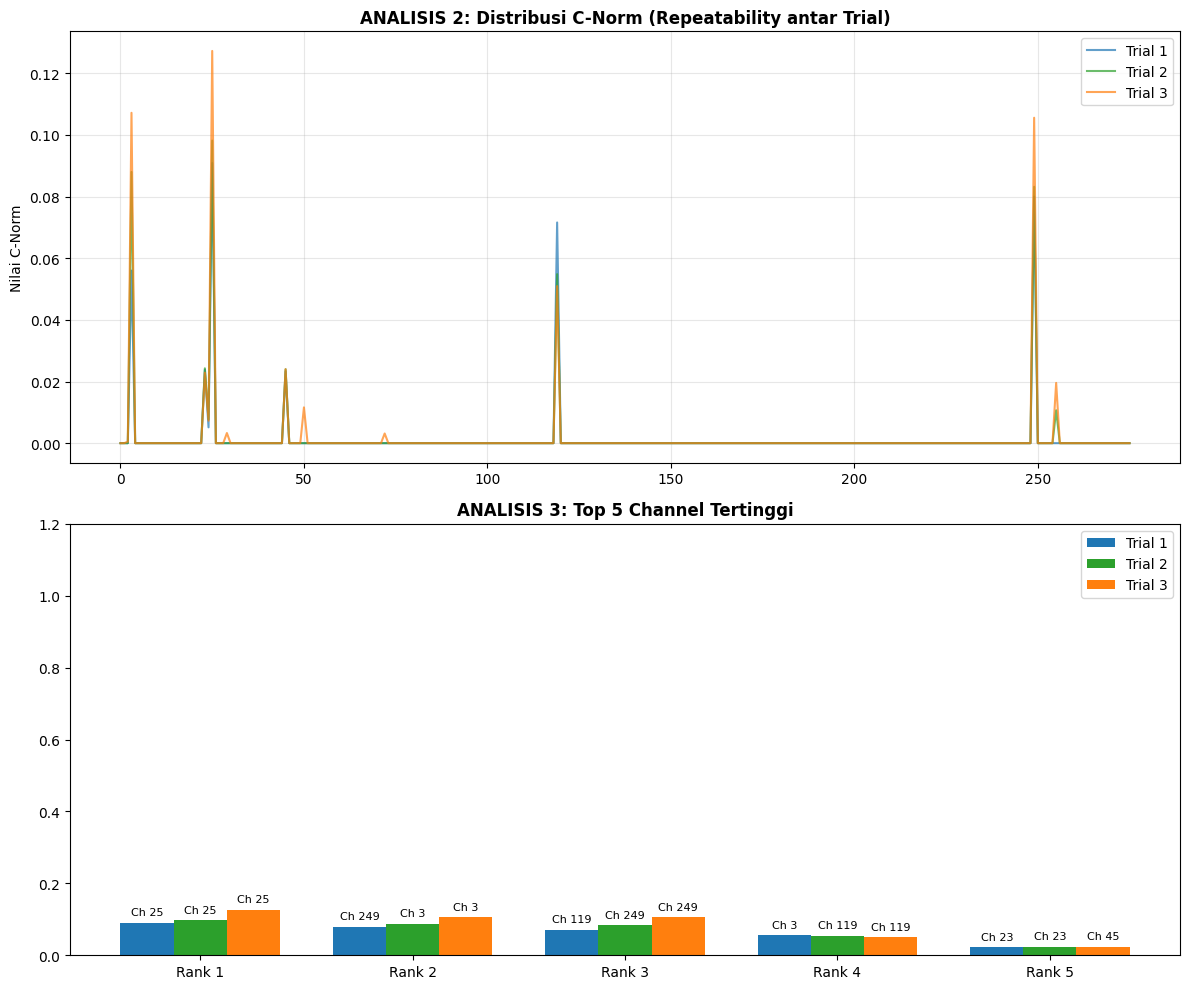


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 45.07      | 311.96     | 0.4308
Trial 2    | 46.30      | 312.00     | 0.3740
Trial 3    | 45.61      | 312.00     | 0.4049
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.01 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 25  | 0.0909        | 25  | 0.0982        | 25  | 0.1273        | 
 #2    | 249 |

In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### KIRI DALAM


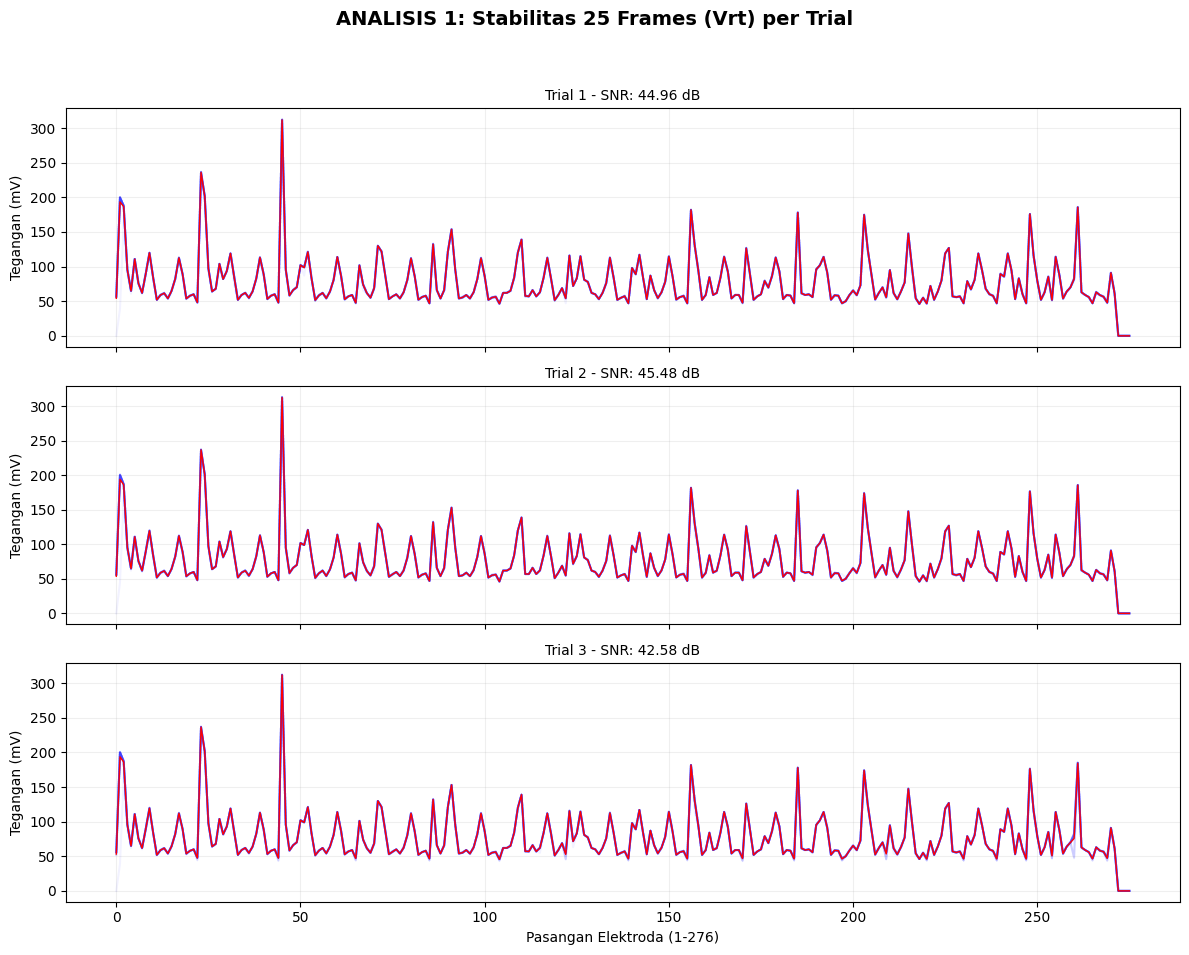

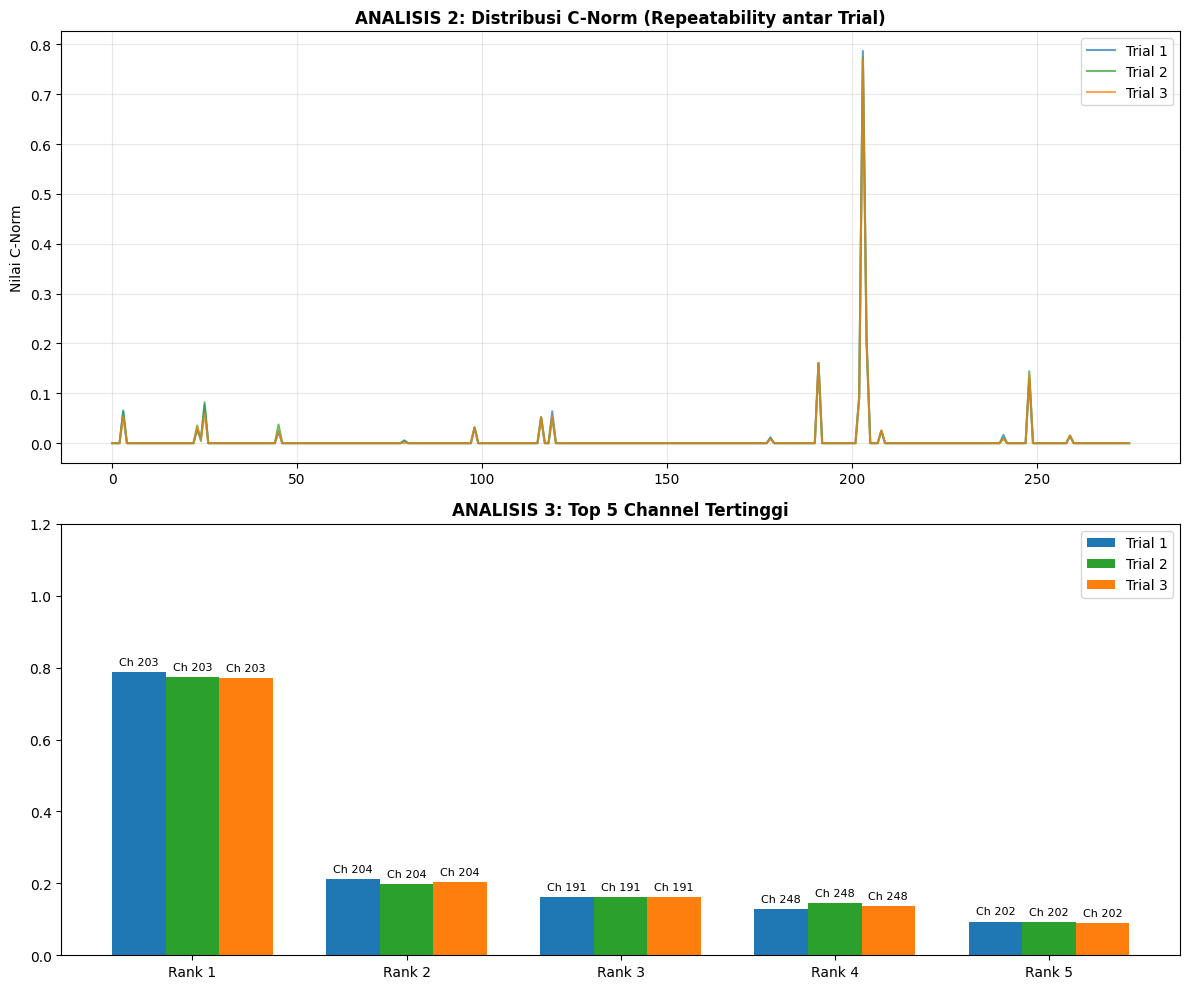


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 44.96      | 311.92     | 0.4379
Trial 2    | 45.48      | 312.84     | 0.4120
Trial 3    | 42.58      | 312.00     | 0.5747
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.13 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 203 | 0.7867        | 203 | 0.7733        | 203 | 0.7712        | 
 #2    | 204 |

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kiri_dalam_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES__breast_24ch_bola_kiri_dalam_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES__breast_24ch_bola_kiri_dalam_menempel_3_dex_planar12ch_26-Jan-2026.dat'
    ]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### KIRI LUAR


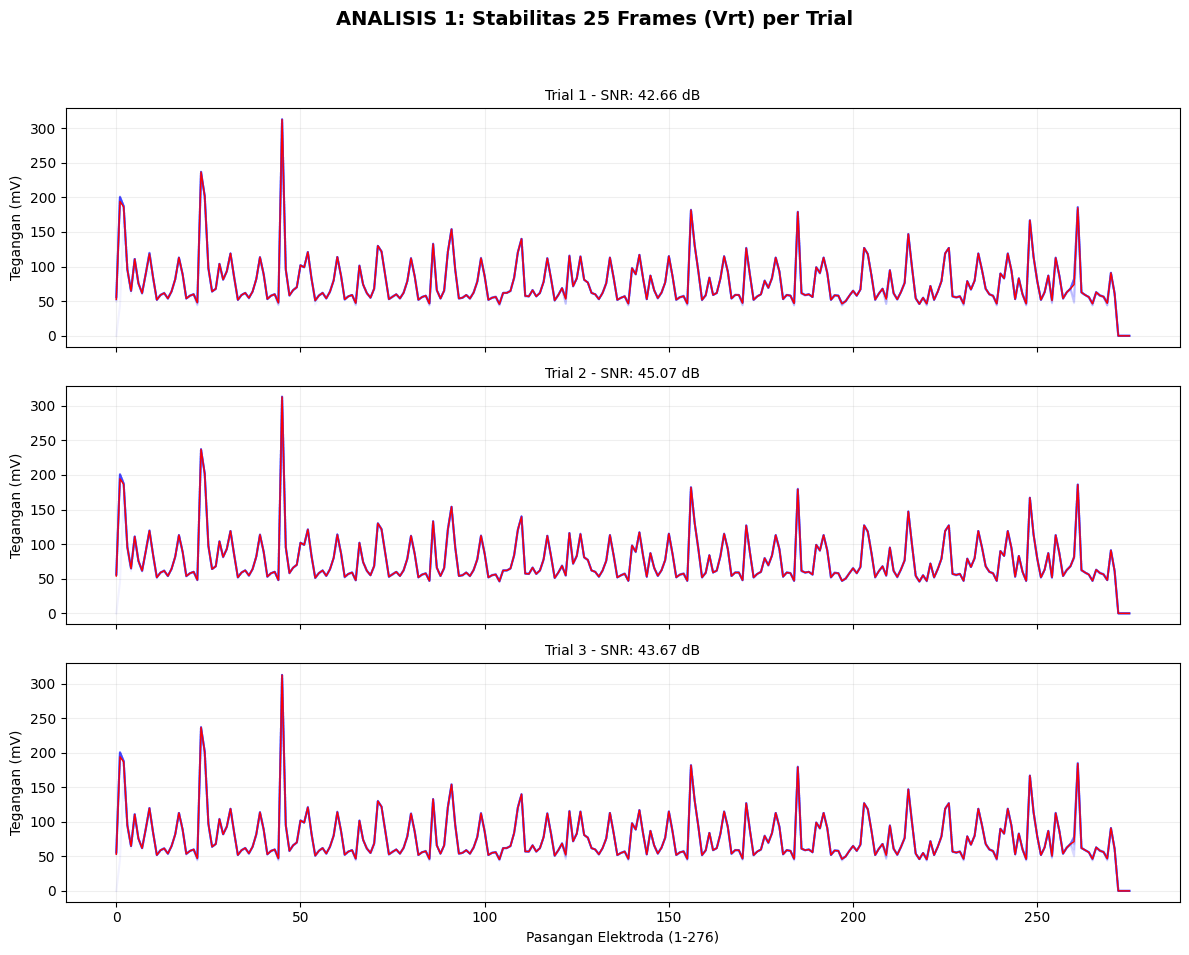

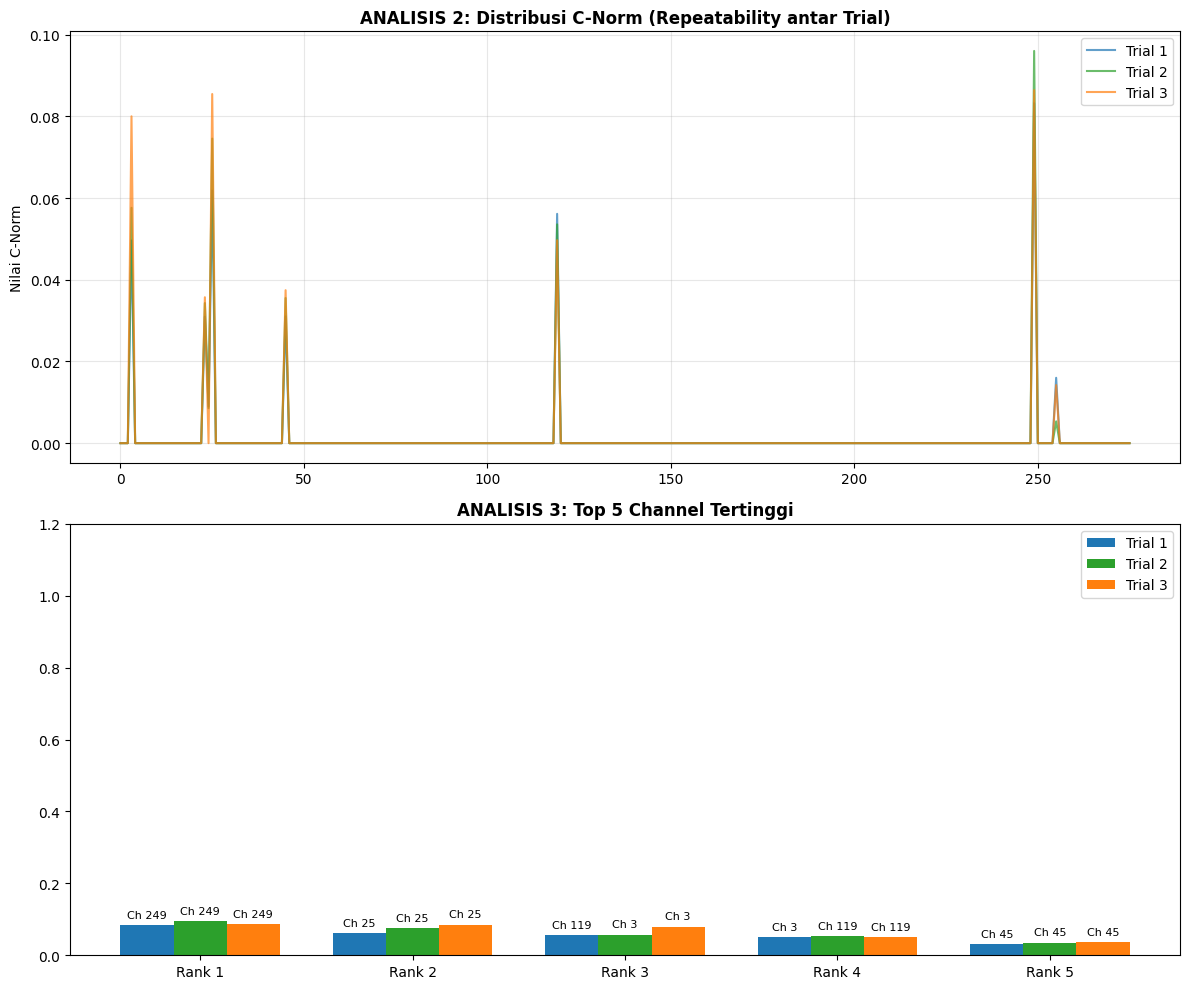


                              RINGKASAN STATISTIK DATA                               
-------------------------------------------------------------------------------------
TRIAL      | SNR (dB)   | PEAK (mV)  | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Trial 1    | 42.66      | 312.44     | 0.5668
Trial 2    | 45.07      | 312.72     | 0.4299
Trial 3    | 43.67      | 312.84     | 0.5042
-------------------------------------------------------------------------------------
Stabilitas Sinyal (RSD): 0.05 %

                     TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)                     
-------------------------------------------------------------------------------------
Rank   | Trial 1 (Ch | Val)     | Trial 2 (Ch | Val)     | Trial 3 (Ch | Val)    
-------------------------------------------------------------------------------------
 #1    | 249 | 0.0832        | 249 | 0.0960        | 249 | 0.0864        | 
 #2    | 25  |

In [9]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI & PATH
# ==========================================
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_1_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_2_dex_planar12ch_26-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\26-Jan-2026\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_3_dex_planar12ch_26-Jan-2026.dat'
]

def analisis_full_komprehensif(paths):
    all_results = []
    
    try:
        # --- A. LOAD REFERENSI KALIBRASI ---
        ref_mat = scipy.io.loadmat(paths[0])
        bes_ref = ref_mat['bes'][0, 0]
        # Ve dan Vf (25 frames x 276 ch) -> dihitung rata-rata per channel
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1) 
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1) 
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10 
        
        # --- B. PROSES TIAP TRIAL ---
        for i, path in enumerate(paths):
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Vrt format (25, 276) -> Transpose menjadi (276, 25)
            vrt_frames = bes['Vrt'].T 
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Normalisasi C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            # Hitung SNR & Top 5
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            idx_sorted = np.argsort(cnorm)[::-1][:5]
            
            all_results.append({
                'name': f'Trial {i+1}',
                'raw_vrt': vrt_frames,
                'mean': mean_ch,
                'std': std_ch,
                'cnorm': cnorm,
                'snr': snr,
                'top_5_idx': idx_sorted,
                'top_5_val': cnorm[idx_sorted],
                'peak': np.max(mean_ch)
            })

        # ==========================================
        # 2. VISUALISASI 1: STABILITAS TEMPORAL (25 FRAMES)
        # ==========================================
        fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        fig1.suptitle('ANALISIS 1: Stabilitas 25 Frames (Vrt) per Trial', fontsize=14, fontweight='bold')
        for i, res in enumerate(all_results):
            axes1[i].plot(res['raw_vrt'], color='blue', alpha=0.05) # 25 garis tipis
            axes1[i].plot(res['mean'], color='red', linewidth=1, label='Rata-rata')
            axes1[i].set_title(f"{res['name']} - SNR: {res['snr']:.2f} dB", fontsize=10)
            axes1[i].set_ylabel('Tegangan (mV)')
            axes1[i].grid(True, alpha=0.2)
        plt.xlabel('Pasangan Elektroda (1-276)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # ==========================================
        # 3. VISUALISASI 2: C-NORM & REPEATABILITY
        # ==========================================
        fig2, (ax_cnorm, ax_bar) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot Garis C-Norm Gabungan
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, res in enumerate(all_results):
            ax_cnorm.plot(res['cnorm'], label=res['name'], color=colors[i], alpha=0.7)
        ax_cnorm.set_title('ANALISIS 2: Distribusi C-Norm (Repeatability antar Trial)', fontweight='bold')
        ax_cnorm.set_ylabel('Nilai C-Norm')
        ax_cnorm.legend()
        ax_cnorm.grid(True, alpha=0.3)

        # Bar Chart Top 5 Ranking
        x_rank = np.arange(5)
        width = 0.25
        for i, res in enumerate(all_results):
            ax_bar.bar(x_rank + (i * width), res['top_5_val'], width, label=res['name'], color=colors[i])
            for j, idx in enumerate(res['top_5_idx']):
                ax_bar.text(j + (i * width), res['top_5_val'][j] + 0.02, f"Ch {idx}", ha='center', fontsize=8)
        
        ax_bar.set_title('ANALISIS 3: Top 5 Channel Tertinggi', fontweight='bold')
        ax_bar.set_xticks(x_rank + width)
        ax_bar.set_xticklabels(['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])
        ax_bar.set_ylim(0, 1.2)
        ax_bar.legend()
        plt.tight_layout()
        plt.show()

        # ==========================================
        # 4. OUTPUT STATISTIK & TABEL RANKING
        # ==========================================
        peak_list = [r['peak'] for r in all_results]
        rsd_sinyal = (np.std(peak_list) / np.mean(peak_list)) * 100

        print("\n" + "="*85)
        print(f"{'RINGKASAN STATISTIK DATA':^85}")
        print("-" * 85)
        print(f"{'TRIAL':<10} | {'SNR (dB)':<10} | {'PEAK (mV)':<10} | {'AVG NOISE (mV)'}")
        print("-" * 85)
        for res in all_results:
            avg_noise = np.mean(res['std'])
            print(f"{res['name']:<10} | {res['snr']:<10.2f} | {res['peak']:<10.2f} | {avg_noise:.4f}")
        print("-" * 85)
        print(f"Stabilitas Sinyal (RSD): {rsd_sinyal:.2f} %")

        print("\n" + "="*85)
        print(f"{'TABEL PERBANDINGAN RANKING CHANNEL (C-NORM)':^85}")
        print("-" * 85)
        print(f"{'Rank':<6} | {'Trial 1 (Ch | Val)':<22} | {'Trial 2 (Ch | Val)':<22} | {'Trial 3 (Ch | Val)':<22}")
        print("-" * 85)
        for r in range(5):
            row = f" #{r+1:<4} | "
            for t in range(len(all_results)):
                ch = all_results[t]['top_5_idx'][r]
                val = all_results[t]['top_5_val'][r]
                row += f"{ch:<3} | {val:<8.4f}      | "
            print(row)
        print("="*85)

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
analisis_full_komprehensif(FILE_PATHS)

### GABUNGAN


SKENARIO             | TOP CHANNEL  | MAX C-NORM
--------------------------------------------------
Center Menempel      | 60           | 0.5600
Center Mengambang    | 4            | 0.0871
Kanan Dalam          | 51           | 0.3000
Kanan Luar           | 4            | 0.1012
Kiri Dalam           | 4            | 0.0776
Kiri Luar            | 4            | 0.0965


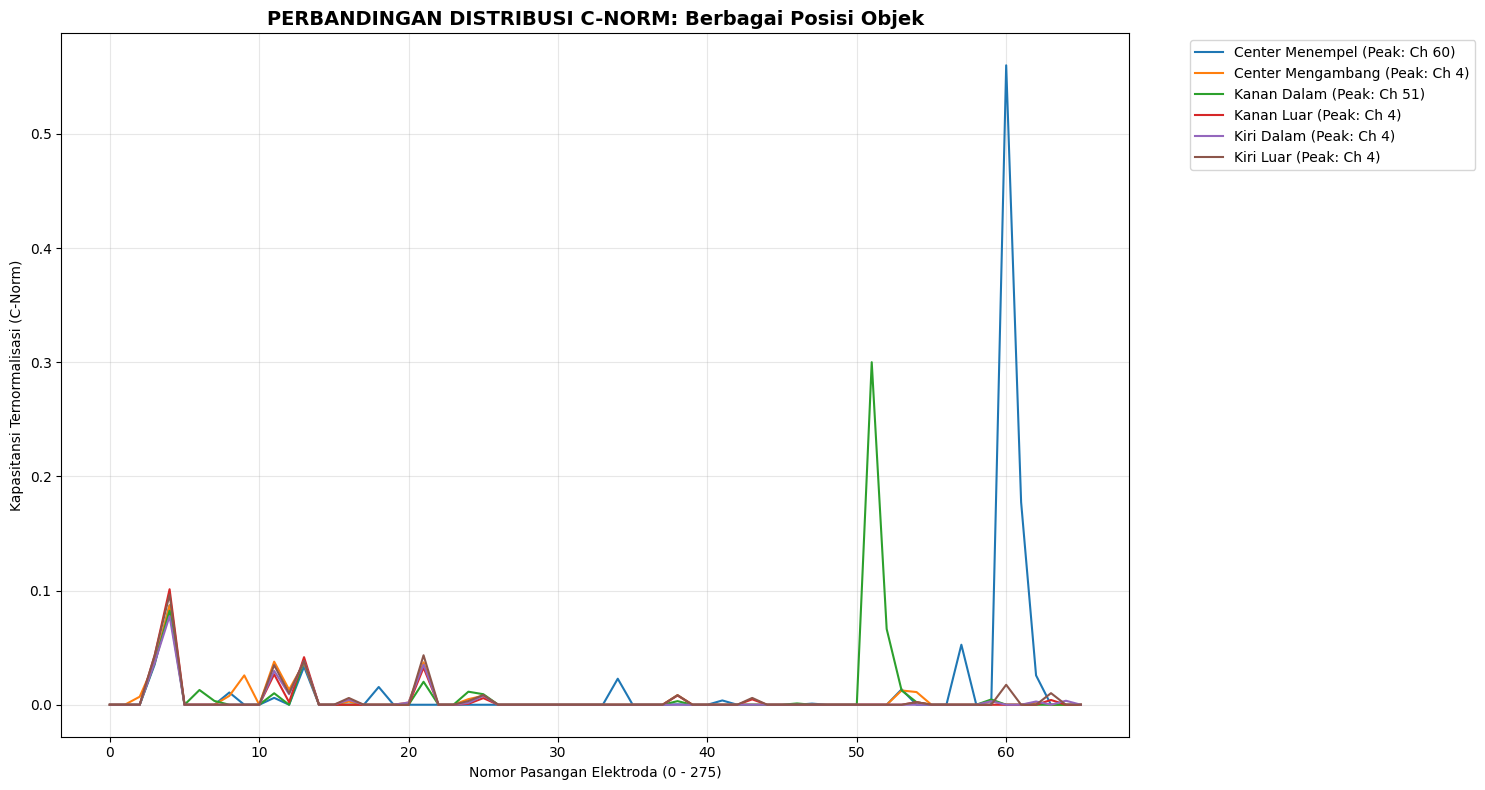

In [17]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI SKENARIO (Sesuaikan Path Anda)
# ==========================================
# Masukkan salah satu path trial atau rata-rata trial untuk tiap skenario
SKENARIOS = {
    'Center Menempel': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Center Mengambang': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_mengambang_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat'
}
def bandingkan_posisi_objek(dict_skenario):
    comparison_data = []

    try:
        # Gunakan skenario pertama sebagai referensi kalibrasi
        ref_path = list(dict_skenario.values())[0]
        ref_mat = scipy.io.loadmat(ref_path)
        bes_ref = ref_mat['bes'][0, 0]
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1)
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1)
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10

        plt.figure(figsize=(15, 8))
        
        print(f"{'SKENARIO':<20} | {'TOP CHANNEL':<12} | {'MAX C-NORM'}")
        print("-" * 50)

        for nama, path in dict_skenario.items():
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            # Ambil rata-rata dari semua frame
            vr_mean = np.mean(bes['Vrt'].T, axis=1)
            
            # Normalisasi
            cnorm = np.clip((vr_mean - ve_avg) / gap, 0, 1)
            
            # Cari Channel Tertinggi
            top_ch = np.argmax(cnorm)
            max_val = cnorm[top_ch]
            
            # Plot ke grafik
            plt.plot(cnorm, label=f"{nama} (Peak: Ch {top_ch})", linewidth=1.5)
            
            print(f"{nama:<20} | {top_ch:<12} | {max_val:.4f}")

        plt.title('PERBANDINGAN DISTRIBUSI C-NORM: Berbagai Posisi Objek', fontsize=14, fontweight='bold')
        plt.xlabel('Nomor Pasangan Elektroda (0 - 275)')
        plt.ylabel('Kapasitansi Ternormalisasi (C-Norm)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Tambahkan visualisasi zona elektroda jika perlu
        # plt.axvspan(0, 66, color='gray', alpha=0.1, label='Zona A') 

        plt.show()

    except Exception as e:
        print(f"Gagal memproses perbandingan: {e}")

# Jalankan perbandingan
bandingkan_posisi_objek(SKENARIOS)


SKENARIO             | SNR (dB)   | AVG GAP (mV)    | AVG NOISE (mV)
-------------------------------------------------------------------------------------
Center Menempel      | 39.35      | 46.72           | 1.1392
Center Mengambang    | 39.55      | 46.72           | 1.1118
Kanan Dalam          | 39.17      | 46.72           | 1.1625
Kanan Luar           | 38.74      | 46.72           | 1.2201
Kiri Dalam           | 39.65      | 46.72           | 1.0978
Kiri Luar            | 39.29      | 46.72           | 1.1466


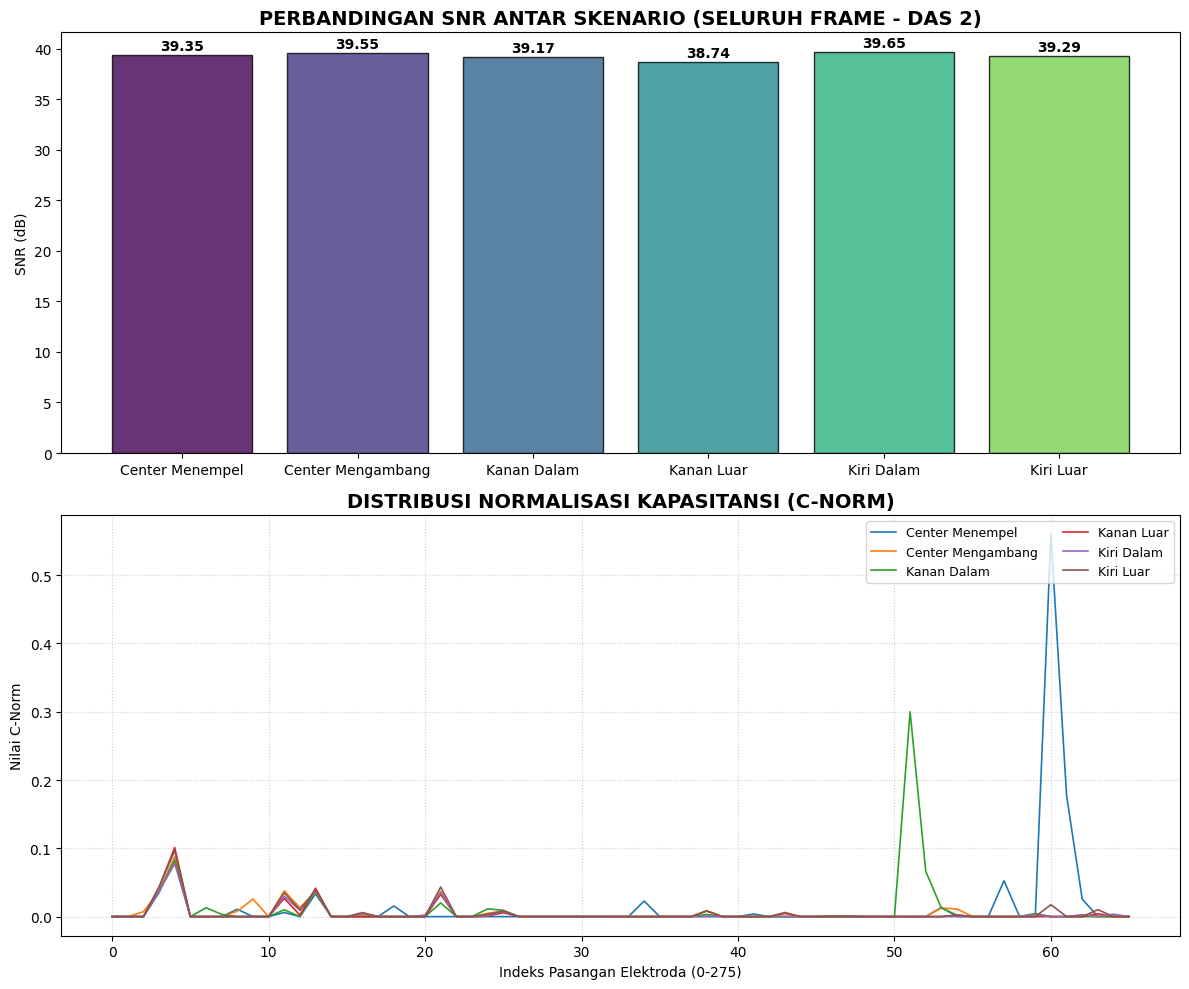

In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI SKENARIO & FILE DAS 2
# ==========================================
SKENARIOS = {
    'Center Menempel': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Center Mengambang': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_mengambang_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat'
}

def analisis_perbandingan_total_das2(dict_skenario):
    names = []
    snr_list = []
    cnorm_list = []
    avg_gap_list = []
    avg_noise_list = []
    
    print("\n" + "="*85)
    print(f"{'SKENARIO':<20} | {'SNR (dB)':<10} | {'AVG GAP (mV)':<15} | {'AVG NOISE (mV)'}")
    print("-" * 85)

    try:
        # --- PROSES DATA ---
        for nama, path in dict_skenario.items():
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            
            # Ekstraksi komponen kalibrasi
            ve_avg_all = np.mean(bes['Ve'].T) 
            vf_avg_all = np.mean(bes['Vf'].T) 
            system_gap = vf_avg_all - ve_avg_all
            
            # --- PENGGUNAAN SELURUH FRAME (TANPA SLICING) ---
            # Menggunakan [:] untuk mengambil semua frame (0-25)
            vrt_frames = bes['Vrt'].T[:, :]  
            
            # Statistik per channel
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Hitung SNR Global (dB)
            avg_signal = np.mean(mean_ch)
            avg_noise = np.mean(std_ch)
            snr = 20 * np.log10(avg_signal / avg_noise) if avg_noise > 0 else 0
            
            # Hitung C-Norm untuk Visualisasi Distribusi
            ve_per_ch = np.mean(bes['Ve'].T, axis=1)
            gap_per_ch = np.mean(bes['Vf'].T, axis=1) - ve_per_ch
            gap_per_ch[gap_per_ch == 0] = 1e-10
            cnorm = np.clip((mean_ch - ve_per_ch) / gap_per_ch, 0, 1)
            
            # Simpan hasil untuk grafik
            names.append(nama)
            snr_list.append(snr)
            cnorm_list.append(cnorm)
            avg_gap_list.append(system_gap)
            avg_noise_list.append(avg_noise)

            # Cetak baris tabel ke konsol
            print(f"{nama:<20} | {snr:<10.2f} | {system_gap:<15.2f} | {avg_noise:.4f}")

        # ==========================================
        # 2. VISUALISASI DASHBOARD
        # ==========================================
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

        # --- PLOT A: SNR BAR CHART ---
        colors = plt.cm.viridis(np.linspace(0, 0.8, len(names)))
        bars = ax1.bar(names, snr_list, color=colors, edgecolor='black', alpha=0.8)
        ax1.set_title('PERBANDINGAN SNR ANTAR SKENARIO (SELURUH FRAME - DAS 2)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('SNR (dB)')
        
        for bar in bars:
            yval = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}", ha='center', fontweight='bold')

        # --- PLOT B: DISTRIBUSI C-NORM ---
        for i in range(len(names)):
            ax2.plot(cnorm_list[i], label=names[i], linewidth=1.2)
        
        ax2.set_title('DISTRIBUSI NORMALISASI KAPASITANSI (C-NORM)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Indeks Pasangan Elektroda (0-275)')
        ax2.set_ylabel('Nilai C-Norm')
        ax2.legend(loc='upper right', ncol=2, fontsize=9)
        ax2.grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        plt.show()
        print("="*85)

    except Exception as e:
        print(f"Error: {e}")

# Jalankan analisis
analisis_perbandingan_total_das2(SKENARIOS)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6320\567506255.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


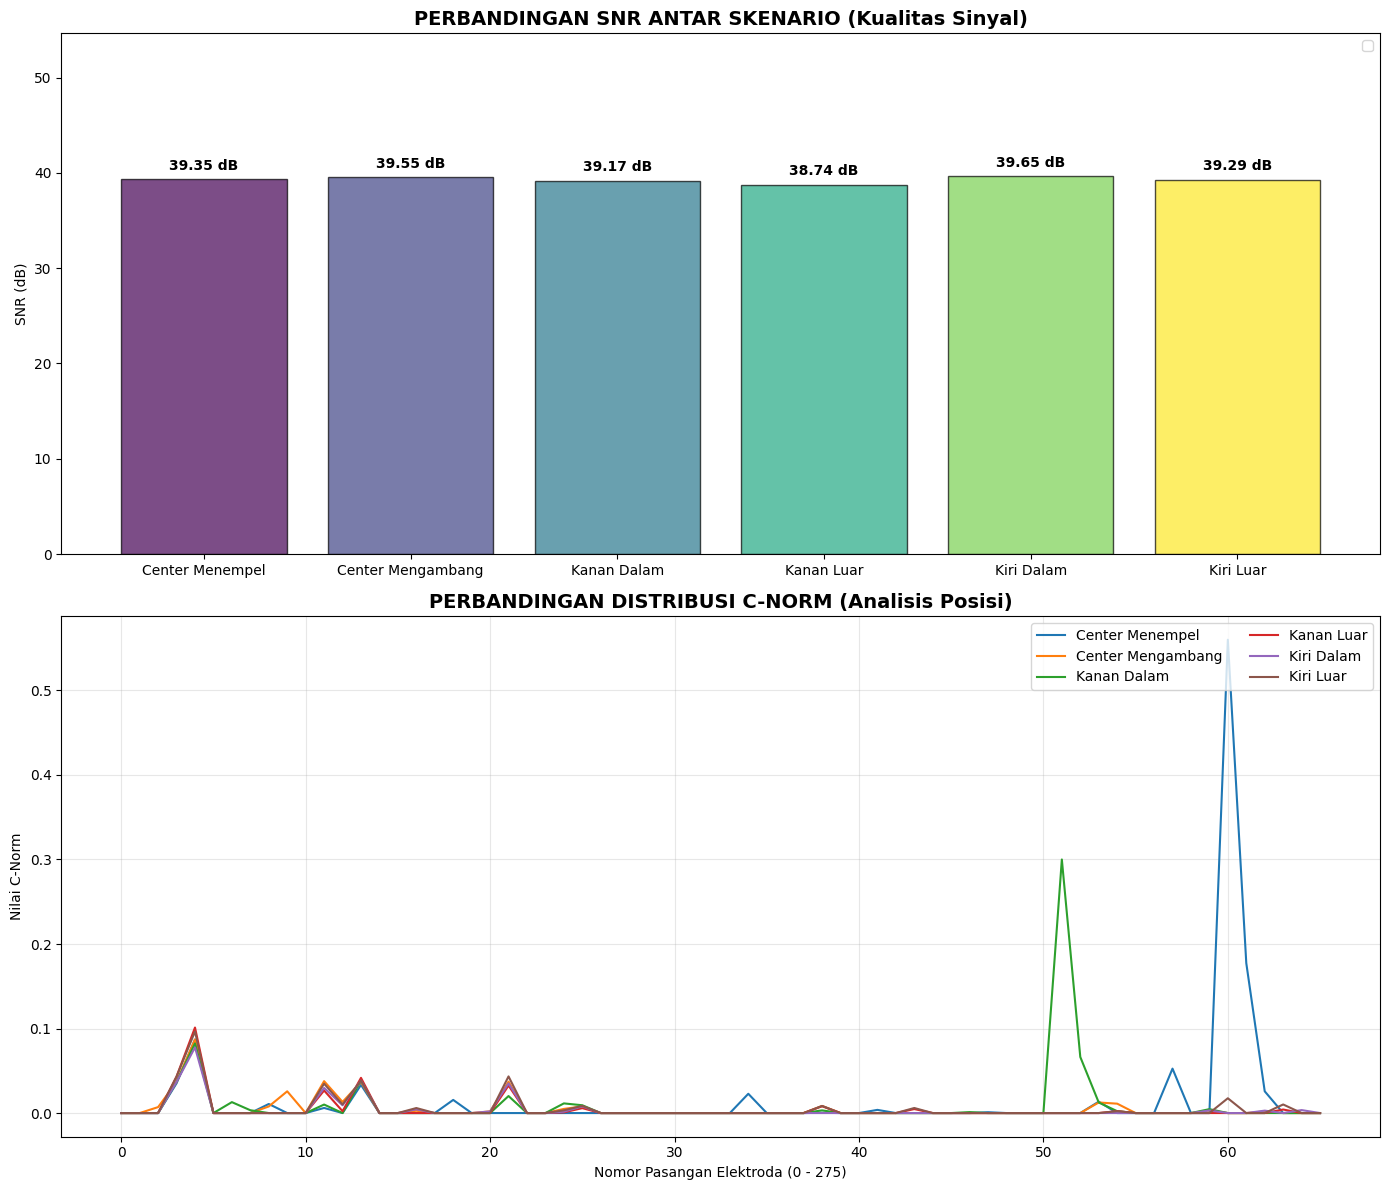


SKENARIO             | SNR (dB)   | PEAK C-NORM
--------------------------------------------------
Center Menempel      | 39.35      | 0.5600
Center Mengambang    | 39.55      | 0.0871
Kanan Dalam          | 39.17      | 0.3000
Kanan Luar           | 38.74      | 0.1012
Kiri Dalam           | 39.65      | 0.0776
Kiri Luar            | 39.29      | 0.0965


In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KONFIGURASI SKENARIO & FILE (Contoh)
# ==========================================
# Masukkan satu path (bisa trial 1 atau rata-rata) untuk setiap skenario
SKENARIOS = {
    'Center Menempel': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Center Mengambang': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_mengambang_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat'
}

def analisis_perbandingan_total(dict_skenario):
    names = []
    snr_list = []
    cnorm_list = []
    
    try:
        # Gunakan file pertama sebagai referensi kalibrasi global
        ref_path = list(dict_skenario.values())[0]
        ref_mat = scipy.io.loadmat(ref_path)
        bes_ref = ref_mat['bes'][0, 0]
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1)
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1)
        gap = vf_avg - ve_avg
        gap[gap == 0] = 1e-10

        # --- PROSES DATA ---
        for nama, path in dict_skenario.items():
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            vrt_frames = bes['Vrt'].T  # (276, 25)
            
            mean_ch = np.mean(vrt_frames, axis=1)
            std_ch = np.std(vrt_frames, axis=1)
            
            # Hitung SNR (dB)
            snr = 20 * np.log10(np.mean(mean_ch) / np.mean(std_ch)) if np.mean(std_ch) > 0 else 0
            
            # Hitung C-Norm
            cnorm = np.clip((mean_ch - ve_avg) / gap, 0, 1)
            
            names.append(nama)
            snr_list.append(snr)
            cnorm_list.append(cnorm)

        # ==========================================
        # 2. VISUALISASI DASHBOARD KOMPARASI
        # ==========================================
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

        # --- PLOT A: PERBANDINGAN SNR (BAR) ---
        colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
        bars = ax1.bar(names, snr_list, color=colors, alpha=0.7, edgecolor='black')
        ax1.set_title('PERBANDINGAN SNR ANTAR SKENARIO (Kualitas Sinyal)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('SNR (dB)')
        ax1.set_ylim(0, max(snr_list) + 15)
        #ax1.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='Threshold Baik (40dB)')
        
        for bar in bars:
            yval = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f} dB", ha='center', fontweight='bold')
        ax1.legend()

        # --- PLOT B: PERBANDINGAN DISTRIBUSI C-NORM (LINE) ---
        for i in range(len(names)):
            ax2.plot(cnorm_list[i], label=names[i], linewidth=1.5)
        
        ax2.set_title('PERBANDINGAN DISTRIBUSI C-NORM (Analisis Posisi)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Nomor Pasangan Elektroda (0 - 275)')
        ax2.set_ylabel('Nilai C-Norm')
        ax2.legend(loc='upper right', ncol=2)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # --- TABEL SUMMARY ---
        print("\n" + "="*50)
        print(f"{'SKENARIO':<20} | {'SNR (dB)':<10} | {'PEAK C-NORM'}")
        print("-" * 50)
        for i in range(len(names)):
            print(f"{names[i]:<20} | {snr_list[i]:<10.2f} | {np.max(cnorm_list[i]):.4f}")
        print("="*50)

    except Exception as e:
        print(f"Error: {e}")

# Jalankan
analisis_perbandingan_total(SKENARIOS)


SKENARIO             | PEAK C-NORM     | SNR NORM (dB)
----------------------------------------------------------------------
Center Menempel      | 0.5625          | 115.00 dB
Center Mengambang    | 0.0527          | 17.36 dB
Kanan Dalam          | 0.3004          | 30.11 dB
Kanan Luar           | 0.0353          | 15.90 dB
Kiri Dalam           | 0.0399          | 21.61 dB
Kiri Luar            | 0.0460          | 17.14 dB


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6320\1929689069.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


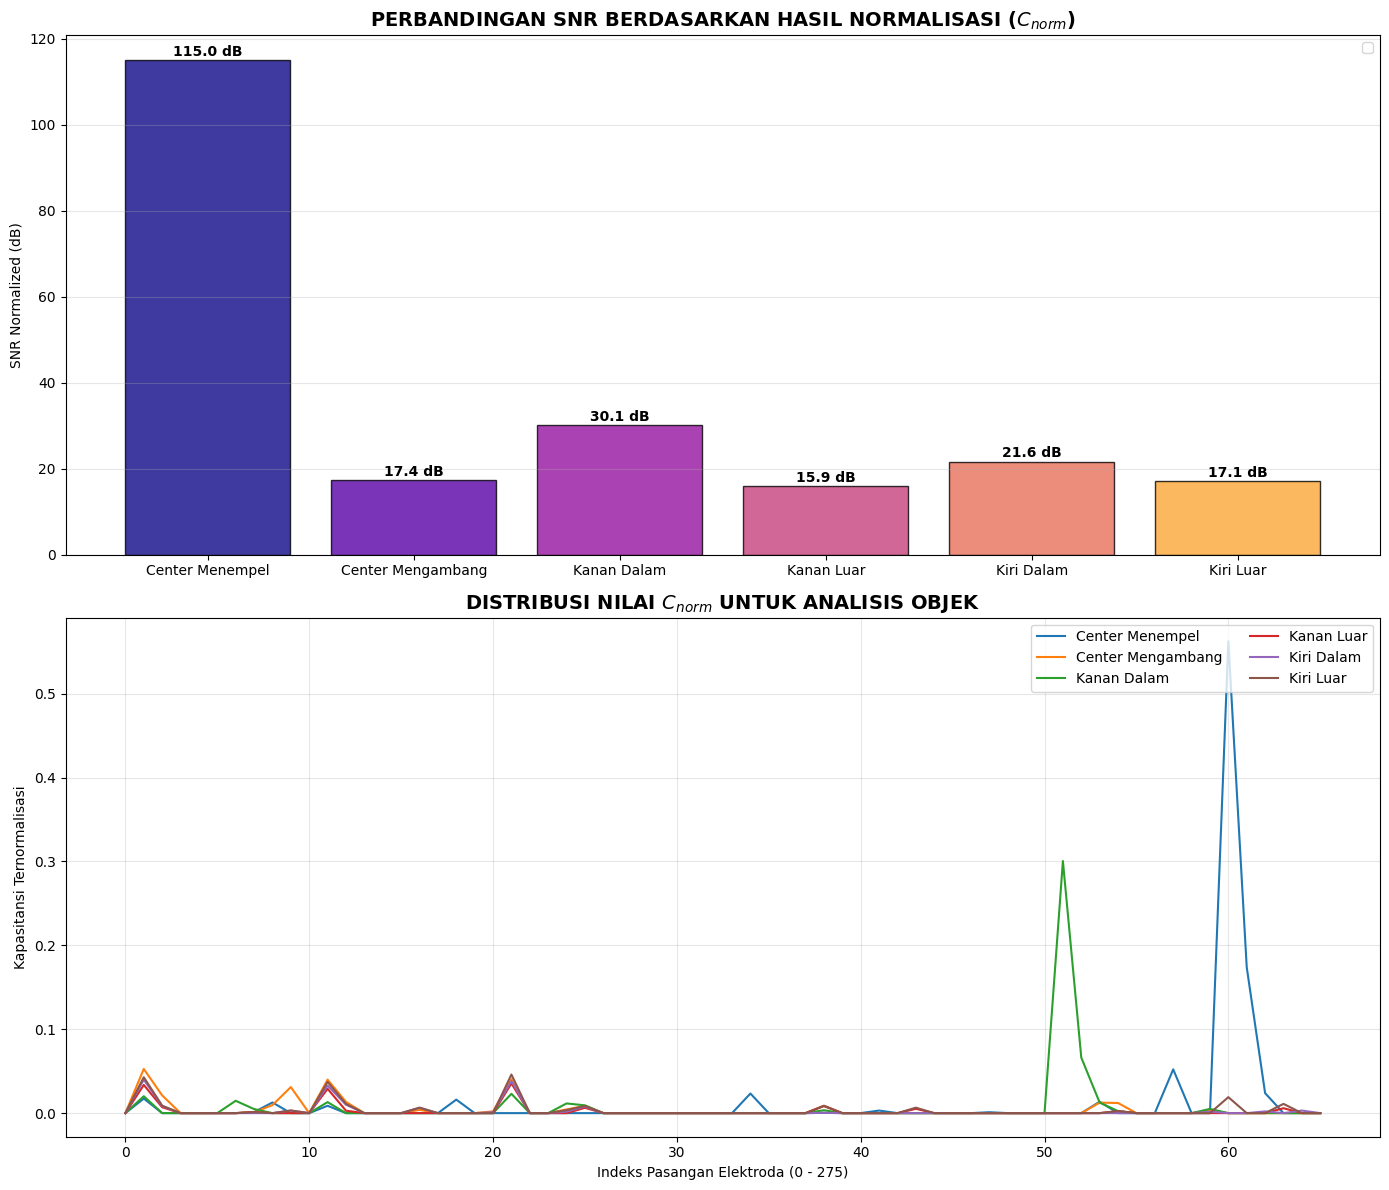

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. KONFIGURASI SKENARIO & FILE
# ==========================================
SKENARIOS = {
    'Center Menempel': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Center Mengambang': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_center_mengambang_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kanan Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kanan_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Dalam': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_dalam_menempel_1_dex_planar12ch_23-Jan-2026.dat',
    'Kiri Luar': r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\2. 24ch Das 2\objek_phantom_bola air_01_21 Jan\[TESTING]_BES_breast_24ch_bola_kiri_luar_menempel_1_dex_planar12ch_23-Jan-2026.dat'
}

def analisis_snr_normalized(dict_skenario):
    names = []
    snr_norm_list = []
    cnorm_avg_list = []
    
    try:
        # Gunakan file pertama sebagai referensi kalibrasi global
        ref_path = list(dict_skenario.values())[0]
        ref_mat = scipy.io.loadmat(ref_path)
        bes_ref = ref_mat['bes'][0, 0]
        
        # Ambil Ve dan Vf (Kalibrasi)
        ve_avg = np.mean(bes_ref['Ve'].T, axis=1)
        vf_avg = np.mean(bes_ref['Vf'].T, axis=1)
        gap = vf_avg - ve_avg
        
        # Tambahkan epsilon kecil untuk menghindari pembagian nol pada gap
        gap[gap <= 0] = 1e-10

        print("\n" + "="*70)
        print(f"{'SKENARIO':<20} | {'PEAK C-NORM':<15} | {'SNR NORM (dB)'}")
        print("-" * 70)

        for nama, path in dict_skenario.items():
            if not os.path.exists(path): continue
            
            mat = scipy.io.loadmat(path)
            bes = mat['bes'][0, 0]
            
            # 1. Ambil data frame (Frame index 2 s.d akhir untuk kestabilan)
            # Transpose agar dimensi menjadi (Channel, Frame) -> (276, 23)
            vrt_frames = bes['Vrt'].T[:, 2:] 
            
            # 2. HITUNG NORMALISASI PER FRAME
            # Melakukan broadcasting agar Ve dan Gap mengurangi tiap frame
            cnorm_frames = (vrt_frames - ve_avg[:, np.newaxis]) / gap[:, np.newaxis]
            
            # 3. ANALISIS STATISTIK DOMAIN NORMALISASI
            avg_cnorm_ch = np.mean(cnorm_frames, axis=1) # Rata-rata C-norm per channel
            std_cnorm_ch = np.std(cnorm_frames, axis=1)  # Noise C-norm per channel
            
            # 4. HITUNG SNR NORMALISASI
            # Kita ukur SNR pada channel yang paling sensitif mendeteksi objek
            top_idx = np.argmax(avg_cnorm_ch)
            signal_norm = avg_cnorm_ch[top_idx]
            noise_norm = std_cnorm_ch[top_idx]
            
            # Menghitung SNR dB (dengan noise floor 1e-6 agar realistis)
            snr_norm = 20 * np.log10(np.abs(signal_norm) / (noise_norm + 1e-6))
            
            # Simpan hasil untuk visualisasi
            names.append(nama)
            snr_norm_list.append(snr_norm)
            cnorm_avg_list.append(np.clip(avg_cnorm_ch, 0, 1))
            
            print(f"{nama:<20} | {np.max(avg_cnorm_ch):<15.4f} | {snr_norm:.2f} dB")

        # ==========================================
        # 2. VISUALISASI
        # ==========================================
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

        # --- PLOT A: SNR NORMALISASI ---
        colors = plt.cm.plasma(np.linspace(0, 0.8, len(names)))
        bars = ax1.bar(names, snr_norm_list, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_title('PERBANDINGAN SNR BERDASARKAN HASIL NORMALISASI ($C_{norm}$)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('SNR Normalized (dB)')
        #ax1.axhline(y=20, color='red', linestyle='--', label='Batas Minimum Citra Layak (20dB)')
        
        for bar in bars:
            yval = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f} dB", ha='center', fontweight='bold')
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)

        # --- PLOT B: DISTRIBUSI C-NORM ---
        for i in range(len(names)):
            ax2.plot(cnorm_avg_list[i], label=names[i], linewidth=1.5)
        
        ax2.set_title('DISTRIBUSI NILAI $C_{norm}$ UNTUK ANALISIS OBJEK', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Indeks Pasangan Elektroda (0 - 275)')
        ax2.set_ylabel('Kapasitansi Ternormalisasi')
        ax2.legend(loc='upper right', ncol=2)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan analisis
analisis_snr_normalized(SKENARIOS)